In [40]:
# --- Librerie Standard e Utilità ---
import os
import json
import random
import numpy as np
from tqdm import tqdm

# --- Machine Learning e Processamento Dati ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# --- Moduli Personalizzati ---
from training_utils import *
from testing_utils import *
from plotting_utils import *
from uncertainty_utils import *


In [41]:
ALL_CSV = ['CBF_ONLY_2',
                 'UECBF_TH025_2',
                 'UECBF_TH050_2',
                 'UECBF_TH075_2',
                 'UECBF_TH090_2',
                 'UECBF_TH099_2',
                 'NO_FILTER_SIMPLE_2']
NEW_CBF = ['CBF_ONLY_3',
            'UECBF_TH025_3',
            'UECBF_TH050_3',
            'UECBF_TH075_3',
            'UECBF_TH090_3',
            'UECBF_TH099_3',
            'NO_FILTER_SIMPLE_3']
ALL_CSV_OOD = ['OOD_CBF_ONLY',
                 'OOD_UECBF_TH025',
                 'OOD_UECBF_TH050',
                 'OOD_UECBF_TH075',
                 'OOD_UECBF_TH090',
                 'OOD_UECBF_TH099',
                 'OOD_NO_FILTER_SIMPLE']
NEW_CBF_OOD = ['OOD_CBF_ONLY_2',
                 'OOD_UECBF_TH025_2',
                 'OOD_UECBF_TH050_2',
                 'OOD_UECBF_TH075_2',
                 'OOD_UECBF_TH090_2',
                 'OOD_UECBF_TH095_2',
                 'OOD_NO_FILTER_SIMPLE_2']
ALL_CSV = [f'./remote_results/{x}.csv' for x in ALL_CSV]
NEW_CBF = [f'./remote_results/{x}.csv' for x in NEW_CBF]
ALL_CSV_OOD = [f'./remote_results/{x}.csv' for x in ALL_CSV_OOD]
NEW_CBF_OOD = [f'./remote_results/{x}.csv' for x in NEW_CBF_OOD]

In [42]:
p_names = [
 'NEW_TR_BASE_5746072',
 'NEW_TR_SIMPLE_5770545',
 'NEW_TR_SIMPLEWP_5819553',
 
 'NEW_TR_SIMPLE_EASY_5804798',
 'NEW_TR_SIMPLEWP_EASY_5841772',
 
 'NEW_TR_PPOBASE_5944633',
 'NEW_TR_PPOSIMPLE_5944623',
 'NEW_TR_LAGPPOSIMPLE_5964789',
 
# 'NEW_TR_LAGSAC_5750993',
 'NEW_TR_LAGSACSIMPLE_5832028',
 ]

In [43]:
metrics = ['success_nc', 'success', 'collisions', 'reward', 'length', 'velocity', 'distance_traveled' ]#  'weighted_success', 'SPL'

In [44]:
all_data = [load_test_from_csv(x, lambda x: x['collisions'] == 0, p_names) for x in NEW_CBF] # , 
all_data_ood1 = [load_test_from_csv(x, lambda x: x['collisions'] == 0, p_names, 'obstacles_ood1') for x in NEW_CBF_OOD] # , 
all_data_ood2 = [load_test_from_csv(x, lambda x: x['collisions'] == 0, p_names, 'obstacles_ood2') for x in NEW_CBF_OOD] # , 
all_data_ood3 = [load_test_from_csv(x, lambda x: x['collisions'] == 0, p_names, 'obstacles_ood3') for x in NEW_CBF_OOD] # , 

Loading data from ./remote_results/CBF_ONLY_3.csv
	1519 data for NEW_TR_BASE_5746072
	1954 data for NEW_TR_SIMPLE_5770545
	1978 data for NEW_TR_SIMPLEWP_5819553
	1941 data for NEW_TR_SIMPLE_EASY_5804798
	1958 data for NEW_TR_SIMPLEWP_EASY_5841772
Loading data from ./remote_results/UECBF_TH025_3.csv
	1538 data for NEW_TR_BASE_5746072
	1955 data for NEW_TR_SIMPLE_5770545
	1978 data for NEW_TR_SIMPLEWP_5819553
	1936 data for NEW_TR_SIMPLE_EASY_5804798
	1952 data for NEW_TR_SIMPLEWP_EASY_5841772
Loading data from ./remote_results/UECBF_TH050_3.csv
	1539 data for NEW_TR_BASE_5746072
	1939 data for NEW_TR_SIMPLE_5770545
	1977 data for NEW_TR_SIMPLEWP_5819553
	1942 data for NEW_TR_SIMPLE_EASY_5804798
	1947 data for NEW_TR_SIMPLEWP_EASY_5841772
Loading data from ./remote_results/UECBF_TH075_3.csv
	1425 data for NEW_TR_BASE_5746072
	1937 data for NEW_TR_SIMPLE_5770545
	1970 data for NEW_TR_SIMPLEWP_5819553
	1922 data for NEW_TR_SIMPLE_EASY_5804798
	1930 data for NEW_TR_SIMPLEWP_EASY_5841772
Loa

In [45]:
all_data[0]['NEW_TR_BASE_5746072'][0].keys()

dict_keys(['id', 'success', 'collisions', 'reward', 'length', 'seed', 'distance_traveled', 'global_avg_dist_obstacle', 'global_avg_visibility', 'global_avg_dispersion', 'global_characteristic_dimension', 'path_tortuosity', 'path_length', 'velocity', 'weighted_success', 'SPL', 'SPL2', 'success_nc'])

In [46]:
all_data_summary = calcola_statistiche_policy(all_data, metrics)
all_data_summary_ood1 = calcola_statistiche_policy(all_data_ood1, metrics)
all_data_summary_ood2 = calcola_statistiche_policy(all_data_ood2, metrics)
all_data_summary_ood3 = calcola_statistiche_policy(all_data_ood3, metrics)

# In Distribution

In [47]:
"SOLO POLICY"
all_data_summary[-1]

,policy_name,success_nc_mean,success_mean,collisions_mean,reward_mean,length_mean,velocity_mean,distance_traveled_mean,success_nc_std,success_std,collisions_std,reward_std,length_std,velocity_std,distance_traveled_std
0,NEW_TR_BASE_5746072,1.000000,1.000000,0.0,13.185827,220.539101,0.018263,4.061612,0.000000,0.000000,0.0,2.163879,128.392497,0.001081,2.381966
1,NEW_TR_SIMPLE_5770545,0.990596,0.990596,0.0,13.440336,305.660920,0.018147,5.297341,0.096544,0.096544,0.0,5.206354,235.072990,0.001829,2.995672
2,NEW_TR_SIMPLEWP_5819553,0.965394,0.965394,0.0,11.950089,364.808142,0.016671,5.157157,0.182825,0.182825,0.0,9.639361,353.502078,0.003075,2.818357
3,NEW_TR_SIMPLE_EASY_5804798,0.995266,0.995266,0.0,13.629487,301.507628,0.018062,5.317179,0.068662,0.068662,0.0,3.889003,208.098230,0.001481,3.053750
4,NEW_TR_SIMPLEWP_EASY_5841772,0.987694,0.987694,0.0,13.481297,291.371322,0.018750,5.129582,0.110277,0.110277,0.0,6.165534,239.358406,0.002105,2.761450
5,NEW_TR_PPOBASE_5944633,1.000000,1.000000,0.0,13.174855,219.696356,0.017725,4.027594,0.000000,0.000000,0.0,2.301771,118.924111,0.001741,2.332066
6,NEW_TR_PPOSIMPLE_5944623,0.999437,0.999437,0.0,13.456613,296.988732,0.016520,4.969841,0.023736,0.023736,0.0,2.682291,157.972001,0.002189,2.699290
7,NEW_TR_LAGPPOSIMPLE_5964789,1.000000,1.000000,0.0,11.214436,440.629207,0.011730,5.253752,0.000000,0.000000,0.0,2.158463,222.712764,0.002010,2.868847
8,NEW_TR_LAGSACSIMPLE_5832028,0.974039,0.974039,0.0,12.580095,330.144341,0.018194,5.284800,0.159059,0.159059,0.0,8.569224,319.543720,0.002800,3.161883


In [48]:
"CBF SEMPRE ATTIVE"
all_data_summary[0]

,policy_name,success_nc_mean,success_mean,collisions_mean,reward_mean,length_mean,velocity_mean,distance_traveled_mean,success_nc_std,success_std,collisions_std,reward_std,length_std,velocity_std,distance_traveled_std
0,NEW_TR_BASE_5746072,0.974984,0.974984,0.0,11.855572,313.576037,0.017345,4.578295,0.156226,0.156226,0.0,8.416734,330.642743,0.003256,2.633773
1,NEW_TR_SIMPLE_5770545,0.979017,0.979017,0.0,12.762974,331.333163,0.017821,5.307288,0.143363,0.143363,0.0,7.481458,299.771618,0.002725,2.963429
2,NEW_TR_SIMPLEWP_5819553,0.961577,0.961577,0.0,11.626475,376.518706,0.016491,5.163386,0.192263,0.192263,0.0,10.200843,371.216144,0.003298,2.823927
3,NEW_TR_SIMPLE_EASY_5804798,0.991242,0.991242,0.0,13.243400,322.793405,0.017823,5.423965,0.093199,0.093199,0.0,5.137725,258.171810,0.002093,3.172009
4,NEW_TR_SIMPLEWP_EASY_5841772,0.970378,0.970378,0.0,12.436662,332.882022,0.018238,5.194129,0.169586,0.169586,0.0,9.025176,334.246929,0.003213,2.787193


In [49]:
"UE + CBF con th 0.9"
all_data_summary[-3]

,policy_name,success_nc_mean,success_mean,collisions_mean,reward_mean,length_mean,velocity_mean,distance_traveled_mean,success_nc_std,success_std,collisions_std,reward_std,length_std,velocity_std,distance_traveled_std
0,NEW_TR_BASE_5746072,0.999206,0.999206,0.0,13.163544,228.314535,0.018178,4.143037,0.028183,0.028183,0.0,2.708905,143.778434,0.001371,2.410718
1,NEW_TR_SIMPLE_5770545,0.989130,0.989130,0.0,13.362105,309.360766,0.018107,5.304821,0.103716,0.103716,0.0,5.575964,242.727316,0.002033,2.959334
2,NEW_TR_SIMPLEWP_5819553,0.964413,0.964413,0.0,11.853135,368.551601,0.016628,5.161327,0.185306,0.185306,0.0,9.802323,360.458127,0.003125,2.825710
3,NEW_TR_SIMPLE_EASY_5804798,0.992685,0.992685,0.0,13.440282,308.607628,0.017969,5.308544,0.085234,0.085234,0.0,4.749677,230.228567,0.001851,2.984631
4,NEW_TR_SIMPLEWP_EASY_5841772,0.982595,0.982595,0.0,13.140851,303.948840,0.018582,5.133054,0.130810,0.130810,0.0,7.177428,271.642810,0.002547,2.769588


# OOD1

In [50]:
"SOLO POLICY"
all_data_summary_ood1[-1]

,policy_name,success_nc_mean,success_mean,collisions_mean,reward_mean,length_mean,velocity_mean,distance_traveled_mean,success_nc_std,success_std,collisions_std,reward_std,length_std,velocity_std,distance_traveled_std
0,NEW_TR_BASE_5746072,1.000000,1.000000,0.0,13.258742,222.232346,0.018354,4.095778,0.000000,0.000000,0.0,2.286344,137.249345,0.000955,2.528821
1,NEW_TR_SIMPLE_5770545,0.987812,0.987812,0.0,13.974170,368.357341,0.017986,6.253375,0.109756,0.109756,0.0,5.582694,273.783415,0.001922,3.472566
2,NEW_TR_SIMPLEWP_5819553,0.924203,0.924203,0.0,10.428748,489.912180,0.016040,5.964547,0.264743,0.264743,0.0,13.680288,482.495153,0.004269,3.319271
3,NEW_TR_SIMPLE_EASY_5804798,0.991789,0.991789,0.0,13.875962,358.410557,0.017796,6.043484,0.090269,0.090269,0.0,5.390828,255.102608,0.002074,3.357149
4,NEW_TR_SIMPLEWP_EASY_5841772,0.985327,0.985327,0.0,14.072368,353.479684,0.018587,6.113201,0.120273,0.120273,0.0,6.515218,277.166903,0.002218,3.312958
5,NEW_TR_PPOBASE_5944633,1.000000,1.000000,0.0,13.289132,221.063715,0.017794,4.067024,0.000000,0.000000,0.0,2.337711,123.487394,0.001626,2.441598
6,NEW_TR_PPOSIMPLE_5944623,0.998732,0.998732,0.0,13.741987,355.301839,0.016069,5.733552,0.035601,0.035601,0.0,3.252660,200.122396,0.002470,3.233981
7,NEW_TR_LAGPPOSIMPLE_5964789,1.000000,1.000000,0.0,11.404585,510.533456,0.011772,6.114388,0.000000,0.000000,0.0,2.567397,263.625341,0.002145,3.430968
8,NEW_TR_LAGSACSIMPLE_5832028,0.949416,0.949416,0.0,11.683140,425.084491,0.017426,5.887999,0.219207,0.219207,0.0,11.787218,423.738607,0.003976,3.344718


In [51]:
"CBF SEMPRE ATTIVE"
all_data_summary_ood1[0]

,policy_name,success_nc_mean,success_mean,collisions_mean,reward_mean,length_mean,velocity_mean,distance_traveled_mean,success_nc_std,success_std,collisions_std,reward_std,length_std,velocity_std,distance_traveled_std
0,NEW_TR_BASE_5746072,0.913380,0.913380,0.0,7.174854,564.767606,0.014212,5.288520,0.281376,0.281376,0.0,13.934556,560.649640,0.005771,3.128053
1,NEW_TR_SIMPLE_5770545,0.880130,0.880130,0.0,4.635425,731.147408,0.013477,6.162160,0.324898,0.324898,0.0,15.461876,662.063913,0.006292,3.453127
2,NEW_TR_SIMPLEWP_5819553,0.853093,0.853093,0.0,3.232399,772.513918,0.012425,5.832483,0.354105,0.354105,0.0,17.183794,672.210419,0.006239,3.295168
3,NEW_TR_SIMPLE_EASY_5804798,0.898286,0.898286,0.0,5.485995,703.960752,0.013593,6.169288,0.302355,0.302355,0.0,14.496034,632.608683,0.006115,3.400113
4,NEW_TR_SIMPLEWP_EASY_5841772,0.867457,0.867457,0.0,4.681911,729.912716,0.013974,6.335684,0.339172,0.339172,0.0,15.729809,672.590829,0.006479,3.687938


In [52]:
"UE + CBF con th 0.9"
all_data_summary_ood1[-3]

,policy_name,success_nc_mean,success_mean,collisions_mean,reward_mean,length_mean,velocity_mean,distance_traveled_mean,success_nc_std,success_std,collisions_std,reward_std,length_std,velocity_std,distance_traveled_std
0,NEW_TR_BASE_5746072,0.995084,0.995084,0.0,12.644308,280.791544,0.017503,4.457424,0.069979,0.069979,0.0,4.854191,244.914089,0.002792,2.663692
1,NEW_TR_SIMPLE_5770545,0.980588,0.980588,0.0,12.756843,417.586245,0.017135,6.203898,0.138007,0.138007,0.0,7.597433,359.371079,0.003349,3.437999
2,NEW_TR_SIMPLEWP_5819553,0.911596,0.911596,0.0,9.223767,535.537181,0.015277,5.921685,0.283955,0.283955,0.0,14.596766,523.885856,0.004746,3.321196
3,NEW_TR_SIMPLE_EASY_5804798,0.959544,0.959544,0.0,11.006752,482.520228,0.016269,6.183635,0.197082,0.197082,0.0,10.170185,454.026742,0.004360,3.502069
4,NEW_TR_SIMPLEWP_EASY_5841772,0.951848,0.951848,0.0,10.356591,497.612542,0.016454,6.009368,0.214148,0.214148,0.0,11.592545,491.921635,0.005074,3.281764


# OOD2

In [53]:
"SOLO POLICY"
all_data_summary_ood2[-1]

,policy_name,success_nc_mean,success_mean,collisions_mean,reward_mean,length_mean,velocity_mean,distance_traveled_mean,success_nc_std,success_std,collisions_std,reward_std,length_std,velocity_std,distance_traveled_std
0,NEW_TR_BASE_5746072,1.000000,1.000000,0.0,12.885200,199.328928,0.018361,3.683687,0.000000,0.000000,0.0,2.063404,125.559093,0.001009,2.314450
1,NEW_TR_SIMPLE_5770545,0.987879,0.987879,0.0,13.385515,328.981818,0.017964,5.525990,0.109469,0.109469,0.0,5.805482,265.861467,0.002035,3.202954
2,NEW_TR_SIMPLEWP_5819553,0.946548,0.946548,0.0,11.108341,411.078693,0.016461,5.370692,0.225017,0.225017,0.0,11.374830,425.444279,0.003687,3.080016
3,NEW_TR_SIMPLE_EASY_5804798,0.996035,0.996035,0.0,13.615767,316.340206,0.017829,5.445629,0.062869,0.062869,0.0,3.951207,221.971990,0.001776,3.165430
4,NEW_TR_SIMPLEWP_EASY_5841772,0.981323,0.981323,0.0,13.320624,322.444358,0.018489,5.422024,0.135434,0.135434,0.0,7.118622,287.567499,0.002425,3.072246
5,NEW_TR_PPOBASE_5944633,1.000000,1.000000,0.0,13.045106,209.807327,0.017630,3.833158,0.000000,0.000000,0.0,2.231485,116.598546,0.001828,2.304882
6,NEW_TR_PPOSIMPLE_5944623,1.000000,1.000000,0.0,13.315325,324.578059,0.015818,5.159066,0.000000,0.000000,0.0,2.631907,176.689129,0.002649,2.911460
7,NEW_TR_LAGPPOSIMPLE_5964789,1.000000,1.000000,0.0,11.087196,460.265233,0.011693,5.464076,0.000000,0.000000,0.0,2.327089,246.967156,0.002158,3.208709
8,NEW_TR_LAGSACSIMPLE_5832028,0.969720,0.969720,0.0,12.304511,352.673913,0.017816,5.341826,0.171422,0.171422,0.0,9.370776,347.818330,0.003189,3.157962


In [54]:
"CBF SEMPRE ATTIVE"
all_data_summary_ood2[0]

,policy_name,success_nc_mean,success_mean,collisions_mean,reward_mean,length_mean,velocity_mean,distance_traveled_mean,success_nc_std,success_std,collisions_std,reward_std,length_std,velocity_std,distance_traveled_std
0,NEW_TR_BASE_5746072,0.940678,0.940678,0.0,8.418523,481.537665,0.014555,4.864870,0.236338,0.236338,0.0,11.906776,495.932581,0.005453,2.957630
1,NEW_TR_SIMPLE_5770545,0.915043,0.915043,0.0,6.825087,583.134840,0.014415,5.438813,0.278927,0.278927,0.0,13.748260,588.898939,0.005853,3.150456
2,NEW_TR_SIMPLEWP_5819553,0.900386,0.900386,0.0,5.749099,621.336680,0.013452,5.277291,0.299600,0.299600,0.0,14.987035,608.974479,0.005840,3.141338
3,NEW_TR_SIMPLE_EASY_5804798,0.923854,0.923854,0.0,7.195307,578.658897,0.014380,5.546766,0.265335,0.265335,0.0,12.962196,573.451752,0.005723,3.219914
4,NEW_TR_SIMPLEWP_EASY_5841772,0.901029,0.901029,0.0,6.537504,587.637371,0.014807,5.494269,0.298741,0.298741,0.0,14.571601,608.326227,0.006074,3.201431


In [55]:
"UE + CBF con th 0.9"
all_data_summary_ood2[-3]

,policy_name,success_nc_mean,success_mean,collisions_mean,reward_mean,length_mean,velocity_mean,distance_traveled_mean,success_nc_std,success_std,collisions_std,reward_std,length_std,velocity_std,distance_traveled_std
0,NEW_TR_BASE_5746072,0.996399,0.996399,0.0,12.669866,266.415366,0.017355,4.319418,0.059940,0.059940,0.0,4.045757,211.659941,0.002634,2.657121
1,NEW_TR_SIMPLE_5770545,0.989426,0.989426,0.0,12.866045,359.710725,0.017198,5.619939,0.102324,0.102324,0.0,5.754039,290.577656,0.002968,3.272892
2,NEW_TR_SIMPLEWP_5819553,0.944279,0.944279,0.0,10.321939,449.405646,0.015627,5.422076,0.229467,0.229467,0.0,11.781661,448.795302,0.004182,3.113285
3,NEW_TR_SIMPLE_EASY_5804798,0.970935,0.970935,0.0,11.135747,427.843676,0.016280,5.572717,0.168055,0.168055,0.0,9.073458,415.946201,0.004210,3.273466
4,NEW_TR_SIMPLEWP_EASY_5841772,0.956890,0.956890,0.0,10.456212,439.223249,0.016565,5.436755,0.203183,0.203183,0.0,10.977059,455.680773,0.004820,3.118643


# OOD3

In [56]:
"SOLO POLICY"
all_data_summary_ood3[-1]

,policy_name,success_nc_mean,success_mean,collisions_mean,reward_mean,length_mean,velocity_mean,distance_traveled_mean,success_nc_std,success_std,collisions_std,reward_std,length_std,velocity_std,distance_traveled_std
0,NEW_TR_BASE_5746072,1.000000,1.000000,0.0,13.141277,212.137705,0.018176,3.895698,0.000000,0.000000,0.0,2.252376,132.381722,0.000941,2.453306
1,NEW_TR_SIMPLE_5770545,1.000000,1.000000,0.0,14.603838,351.707776,0.017881,6.195241,0.000000,0.000000,0.0,2.445276,192.716489,0.001132,3.182907
2,NEW_TR_SIMPLEWP_5819553,0.976914,0.976914,0.0,13.277305,409.622185,0.016704,6.138047,0.150218,0.150218,0.0,8.201174,320.706083,0.002623,3.145688
3,NEW_TR_SIMPLE_EASY_5804798,0.999399,0.999399,0.0,14.476662,356.957357,0.017594,6.132760,0.024507,0.024507,0.0,2.942360,200.065683,0.001444,3.097356
4,NEW_TR_SIMPLEWP_EASY_5841772,0.998778,0.998778,0.0,14.852213,327.045816,0.018635,6.041926,0.034943,0.034943,0.0,3.204248,174.857101,0.000941,3.002930
5,NEW_TR_PPOBASE_5944633,1.000000,1.000000,0.0,13.458405,229.869393,0.017645,4.208184,0.000000,0.000000,0.0,2.436556,126.433153,0.001675,2.510492
6,NEW_TR_PPOSIMPLE_5944623,1.000000,1.000000,0.0,13.980854,356.531104,0.016025,5.740620,0.000000,0.000000,0.0,2.663884,182.339655,0.002283,2.994361
7,NEW_TR_LAGPPOSIMPLE_5964789,1.000000,1.000000,0.0,11.440184,528.006651,0.011606,6.197493,0.000000,0.000000,0.0,2.406554,250.849464,0.001924,3.168883
8,NEW_TR_LAGSACSIMPLE_5832028,0.983891,0.983891,0.0,13.530487,373.315366,0.017681,5.968704,0.125934,0.125934,0.0,7.137823,293.581855,0.002592,3.089642


In [57]:
"CBF SEMPRE ATTIVE"
all_data_summary_ood3[0]

,policy_name,success_nc_mean,success_mean,collisions_mean,reward_mean,length_mean,velocity_mean,distance_traveled_mean,success_nc_std,success_std,collisions_std,reward_std,length_std,velocity_std,distance_traveled_std
0,NEW_TR_BASE_5746072,0.959720,0.959720,0.0,9.307534,495.072680,0.014652,5.269524,0.196702,0.196702,0.0,10.508337,474.065347,0.005212,3.031622
1,NEW_TR_SIMPLE_5770545,0.958011,0.958011,0.0,8.048220,652.448066,0.013568,6.515517,0.200619,0.200619,0.0,10.231876,525.455732,0.005449,3.370318
2,NEW_TR_SIMPLEWP_5819553,0.931034,0.931034,0.0,7.173542,669.439933,0.013047,6.208382,0.253466,0.253466,0.0,12.516423,553.292170,0.005407,3.192377
3,NEW_TR_SIMPLE_EASY_5804798,0.948718,0.948718,0.0,7.812582,649.190313,0.013529,6.326836,0.220635,0.220635,0.0,11.022676,532.207479,0.005511,3.199108
4,NEW_TR_SIMPLEWP_EASY_5841772,0.931530,0.931530,0.0,7.612470,653.960243,0.014013,6.506143,0.252621,0.252621,0.0,11.592844,556.406072,0.005796,3.425755


In [58]:
"UE + CBF con th 0.9"
all_data_summary_ood3[-3]

,policy_name,success_nc_mean,success_mean,collisions_mean,reward_mean,length_mean,velocity_mean,distance_traveled_mean,success_nc_std,success_std,collisions_std,reward_std,length_std,velocity_std,distance_traveled_std
0,NEW_TR_BASE_5746072,0.989765,0.989765,0.0,11.964476,357.972364,0.016279,4.927804,0.100703,0.100703,0.0,6.521134,318.205799,0.003962,2.873631
1,NEW_TR_SIMPLE_5770545,0.988082,0.988082,0.0,11.113613,517.116913,0.015075,6.329623,0.108549,0.108549,0.0,7.170924,402.058552,0.004642,3.221731
2,NEW_TR_SIMPLEWP_5819553,0.949944,0.949944,0.0,9.122999,584.459399,0.013993,6.114486,0.218120,0.218120,0.0,11.462682,491.580299,0.004952,3.132760
3,NEW_TR_SIMPLE_EASY_5804798,0.967517,0.967517,0.0,9.672013,566.398492,0.014495,6.222768,0.177329,0.177329,0.0,9.690036,466.809741,0.005110,3.153226
4,NEW_TR_SIMPLEWP_EASY_5841772,0.972503,0.972503,0.0,9.569421,573.221661,0.014762,6.291342,0.163573,0.163573,0.0,9.512962,481.274173,0.005452,3.170122


In [59]:
import pandas as pd

def affianca_dataframe_per_metrica(df1, df2, df3, metrica):
    colonne_da_isolare = ['policy_name', f'{metrica}_mean', f'{metrica}_std']
    
    d1 = df1[colonne_da_isolare].groupby('policy_name').mean()
    d2 = df2[colonne_da_isolare].groupby('policy_name').mean()
    d3 = df3[colonne_da_isolare].groupby('policy_name').mean()
    
    df_unito = pd.concat([d1, d2, d3], axis=1, keys=['df1', 'df2', 'df3'])
    
    nomi_colonne_piatte = []
    for sorgente, nome_originale in df_unito.columns:
        nuovo_nome = f"{nome_originale}_{sorgente}"
        nomi_colonne_piatte.append(nuovo_nome)
        
    df_unito.columns = nomi_colonne_piatte
    df_unito = df_unito.reset_index()
    
    return df_unito

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize

def multy_plot_traiettorie(
    lista_dataframe,
    m1,
    m2,
    policies,
    ncols=3,
    cmap_name="plasma",
    assi_globali=True,   # <--- NUOVO: toggle per scala X/Y uguale per tutti
):
    """
    Crea una griglia di grafici.
    - Se assi_globali=True: stessa scala X/Y per tutti i subplot (globale).
    - Se assi_globali=False: ogni subplot autoscale (ma colore sempre globale).
    """

    # --- 1. Preparazione dei Dati ---
    df_uniti = []
    for indice, df in enumerate(lista_dataframe):
        df_temp = df.copy()
        df_temp["Iterazione"] = indice
        df_uniti.append(df_temp)

    df_completo = pd.concat(df_uniti, ignore_index=True)

    # Filtriamo per policies (serve sia per colori globali che per limiti globali assi)
    df_filtrato = df_completo[df_completo["policy_name"].isin(policies)]

    # --- 2. Limiti globali per la scala colori (SEMPRE) ---
    min_iter_globale = df_filtrato["Iterazione"].min()
    max_iter_globale = df_filtrato["Iterazione"].max()
    norm_colore = Normalize(vmin=min_iter_globale, vmax=max_iter_globale)

    # --- 3. Setup della Colormap ---
    def truncate_cmap(cmap_obj, vmin=0.1, vmax=0.9, n=256):
        return LinearSegmentedColormap.from_list(
            f"trunc_{cmap_obj.name}", cmap_obj(np.linspace(vmin, vmax, n))
        )

    cmap = truncate_cmap(plt.get_cmap(cmap_name), 0.1, 0.85)

    # --- 4. (OPZIONALE) Calcolo limiti globali per assi X/Y ---
    limiti_x = limiti_y = None
    if assi_globali:
        min_x_globale = df_filtrato[f"{m1}_mean"].min()
        max_x_globale = df_filtrato[f"{m1}_mean"].max()

        min_y_globale = df_filtrato[f"{m2}_mean"].min()
        max_y_globale = df_filtrato[f"{m2}_mean"].max()

        margine_x = (max_x_globale - min_x_globale) * 0.05 if max_x_globale != min_x_globale else 0.1
        margine_y = (max_y_globale - min_y_globale) * 0.05 if max_y_globale != min_y_globale else 0.1

        limiti_x = (min_x_globale - margine_x, max_x_globale + margine_x)
        limiti_y = (min_y_globale - margine_y, max_y_globale + margine_y)

    # --- 5. Creazione della Griglia ---
    nrows = math.ceil(len(policies) / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 5 * nrows))
    axes_flat = np.atleast_1d(axes).flatten()

    # --- 6. Disegno per ogni Policy ---
    for i, policy in enumerate(policies):
        ax = axes_flat[i]

        dati_policy = (
            df_completo[df_completo["policy_name"] == policy]
            .sort_values(by="Iterazione")
        )

        if dati_policy.empty:
            ax.set_title(f"Policy: {policy} (Nessun dato)", fontsize=14)
            ax.grid(True, linestyle="--", alpha=0.4)
            continue

        x_vals = dati_policy[f"{m1}_mean"].values
        y_vals = dati_policy[f"{m2}_mean"].values
        color_vals = dati_policy["Iterazione"].values

        # --- Segmenti sfumati ---
        points = np.column_stack([x_vals, y_vals]).reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        if len(color_vals) > 1:
            seg_vals = (color_vals[:-1] + color_vals[1:]) / 2
            lc = LineCollection(
                segments,
                array=seg_vals,
                cmap=cmap,
                norm=norm_colore,   # colore sempre globale
                linewidths=2,
                alpha=0.8,
                zorder=1,
            )
            ax.add_collection(lc)

        # --- Punti ---
        sc = ax.scatter(
            x_vals,
            y_vals,
            c=color_vals,
            cmap=cmap,
            norm=norm_colore,     # colore sempre globale
            s=50,
            edgecolors="black",
            linewidths=0.4,
            zorder=2,
        )

        # --- Assi: globali o autoscale ---
        if assi_globali:
            ax.set_xlim(limiti_x)
            ax.set_ylim(limiti_y)
        else:
            # autoscale sui dati presenti nel subplot (lascia fare a matplotlib)
            ax.autoscale(enable=True, axis="both", tight=False)

        # --- Dettagli grafico ---
        ax.set_title(f"Traiettoria: {policy}", fontsize=14)
        ax.set_xlabel(f"mean {m1}", fontsize=12)
        ax.set_ylabel(f"mean {m2}", fontsize=12)
        ax.grid(True, linestyle="--", alpha=0.4)

        # Colorbar per subplot (come nel tuo codice)
        cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_ticks([])
        cbar.set_label("tau", fontsize=10)

    # --- 7. Pulizia subplot vuoti ---
    for j in range(len(policies), len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout()
    return fig

# IN DISTRIBUTION

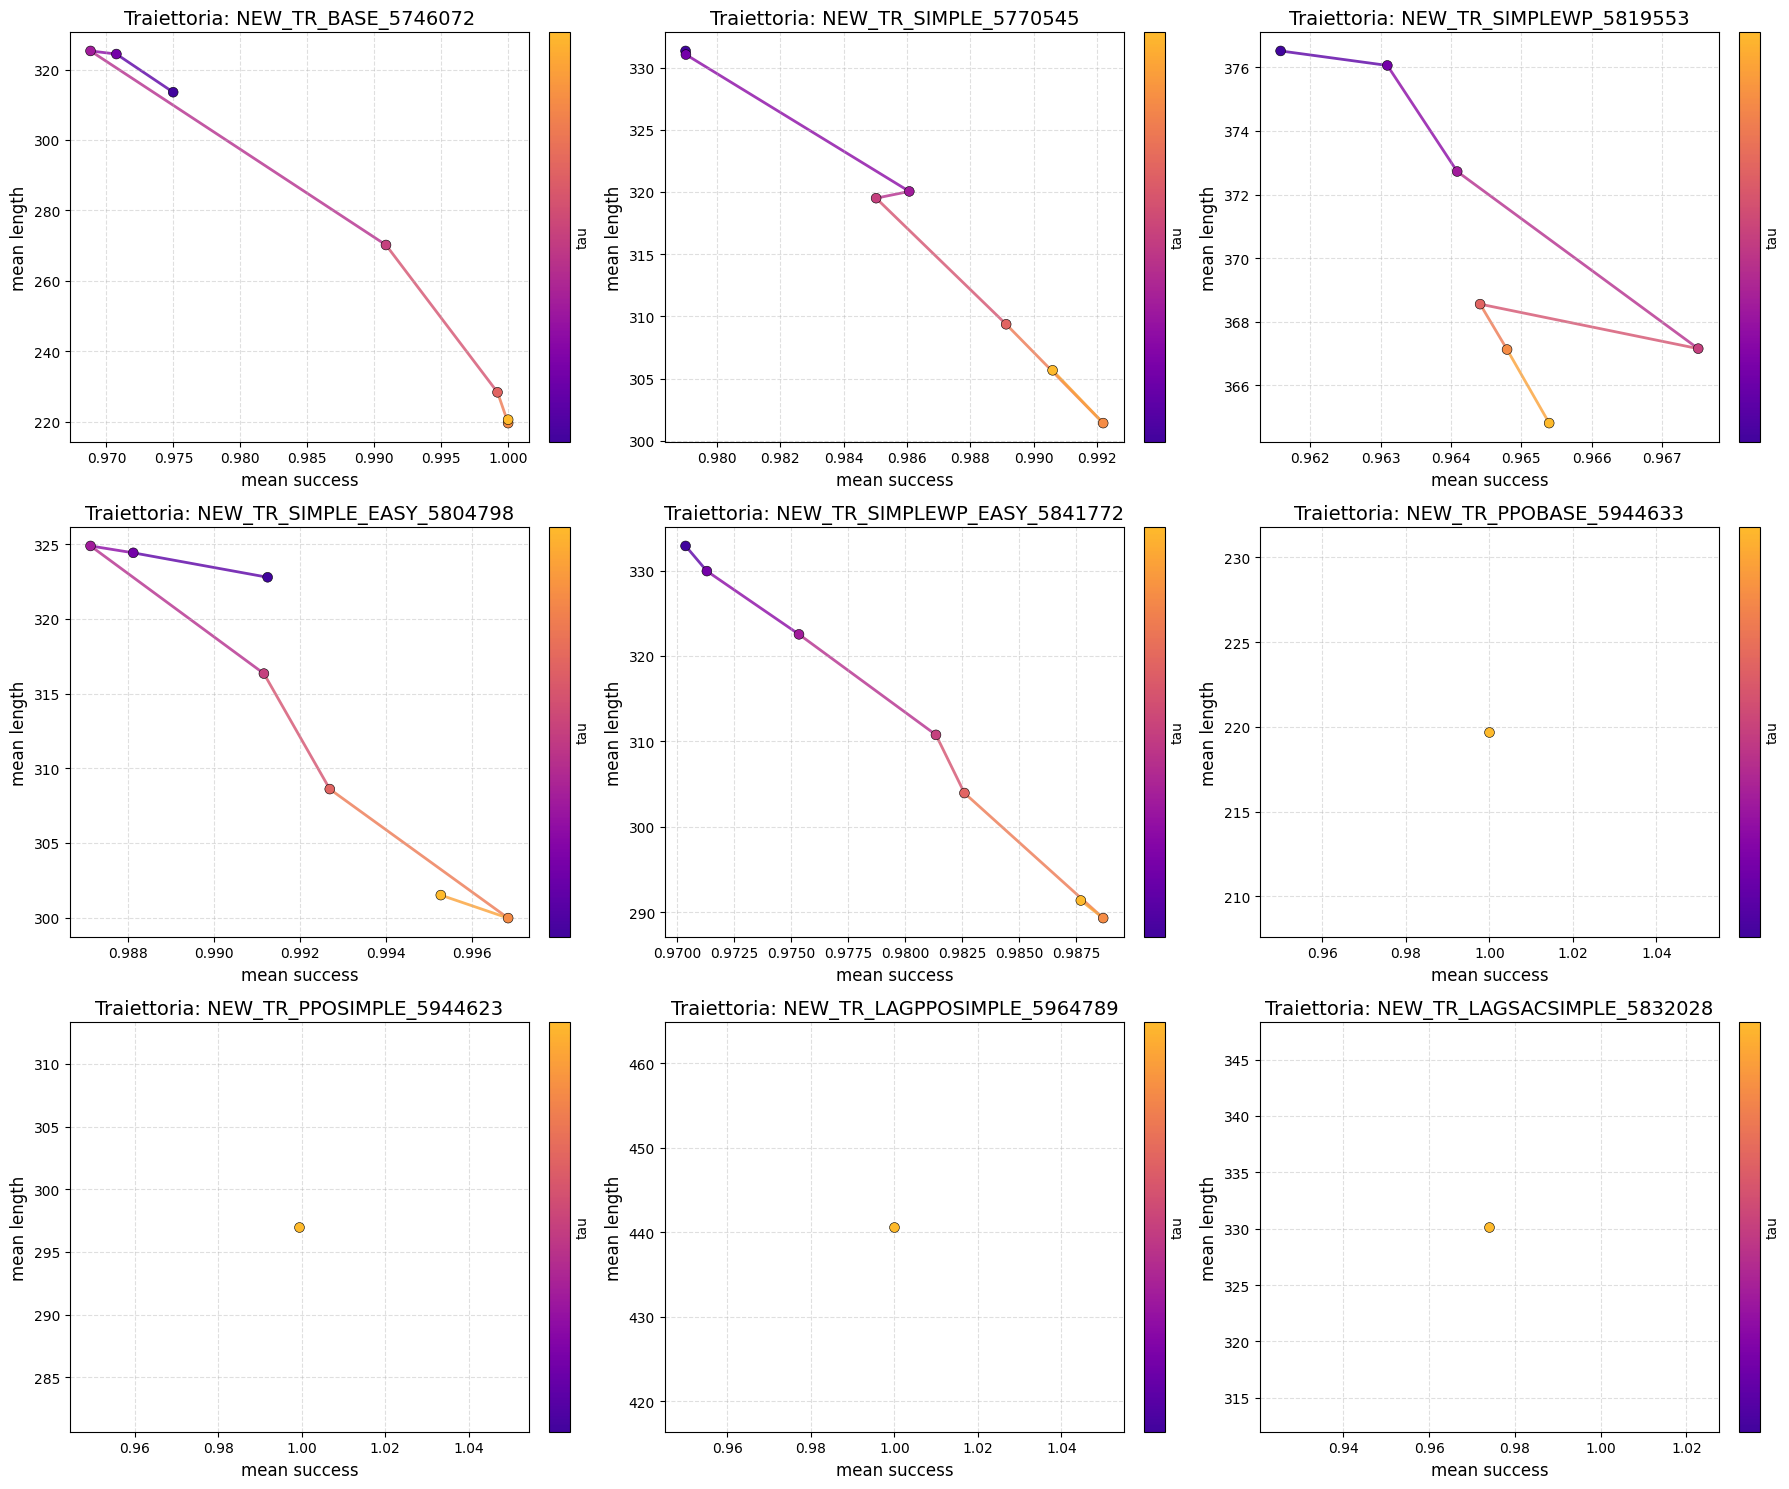

In [71]:
multy_plot_traiettorie(all_data_summary, 'success', 'length', p_names, assi_globali=False);

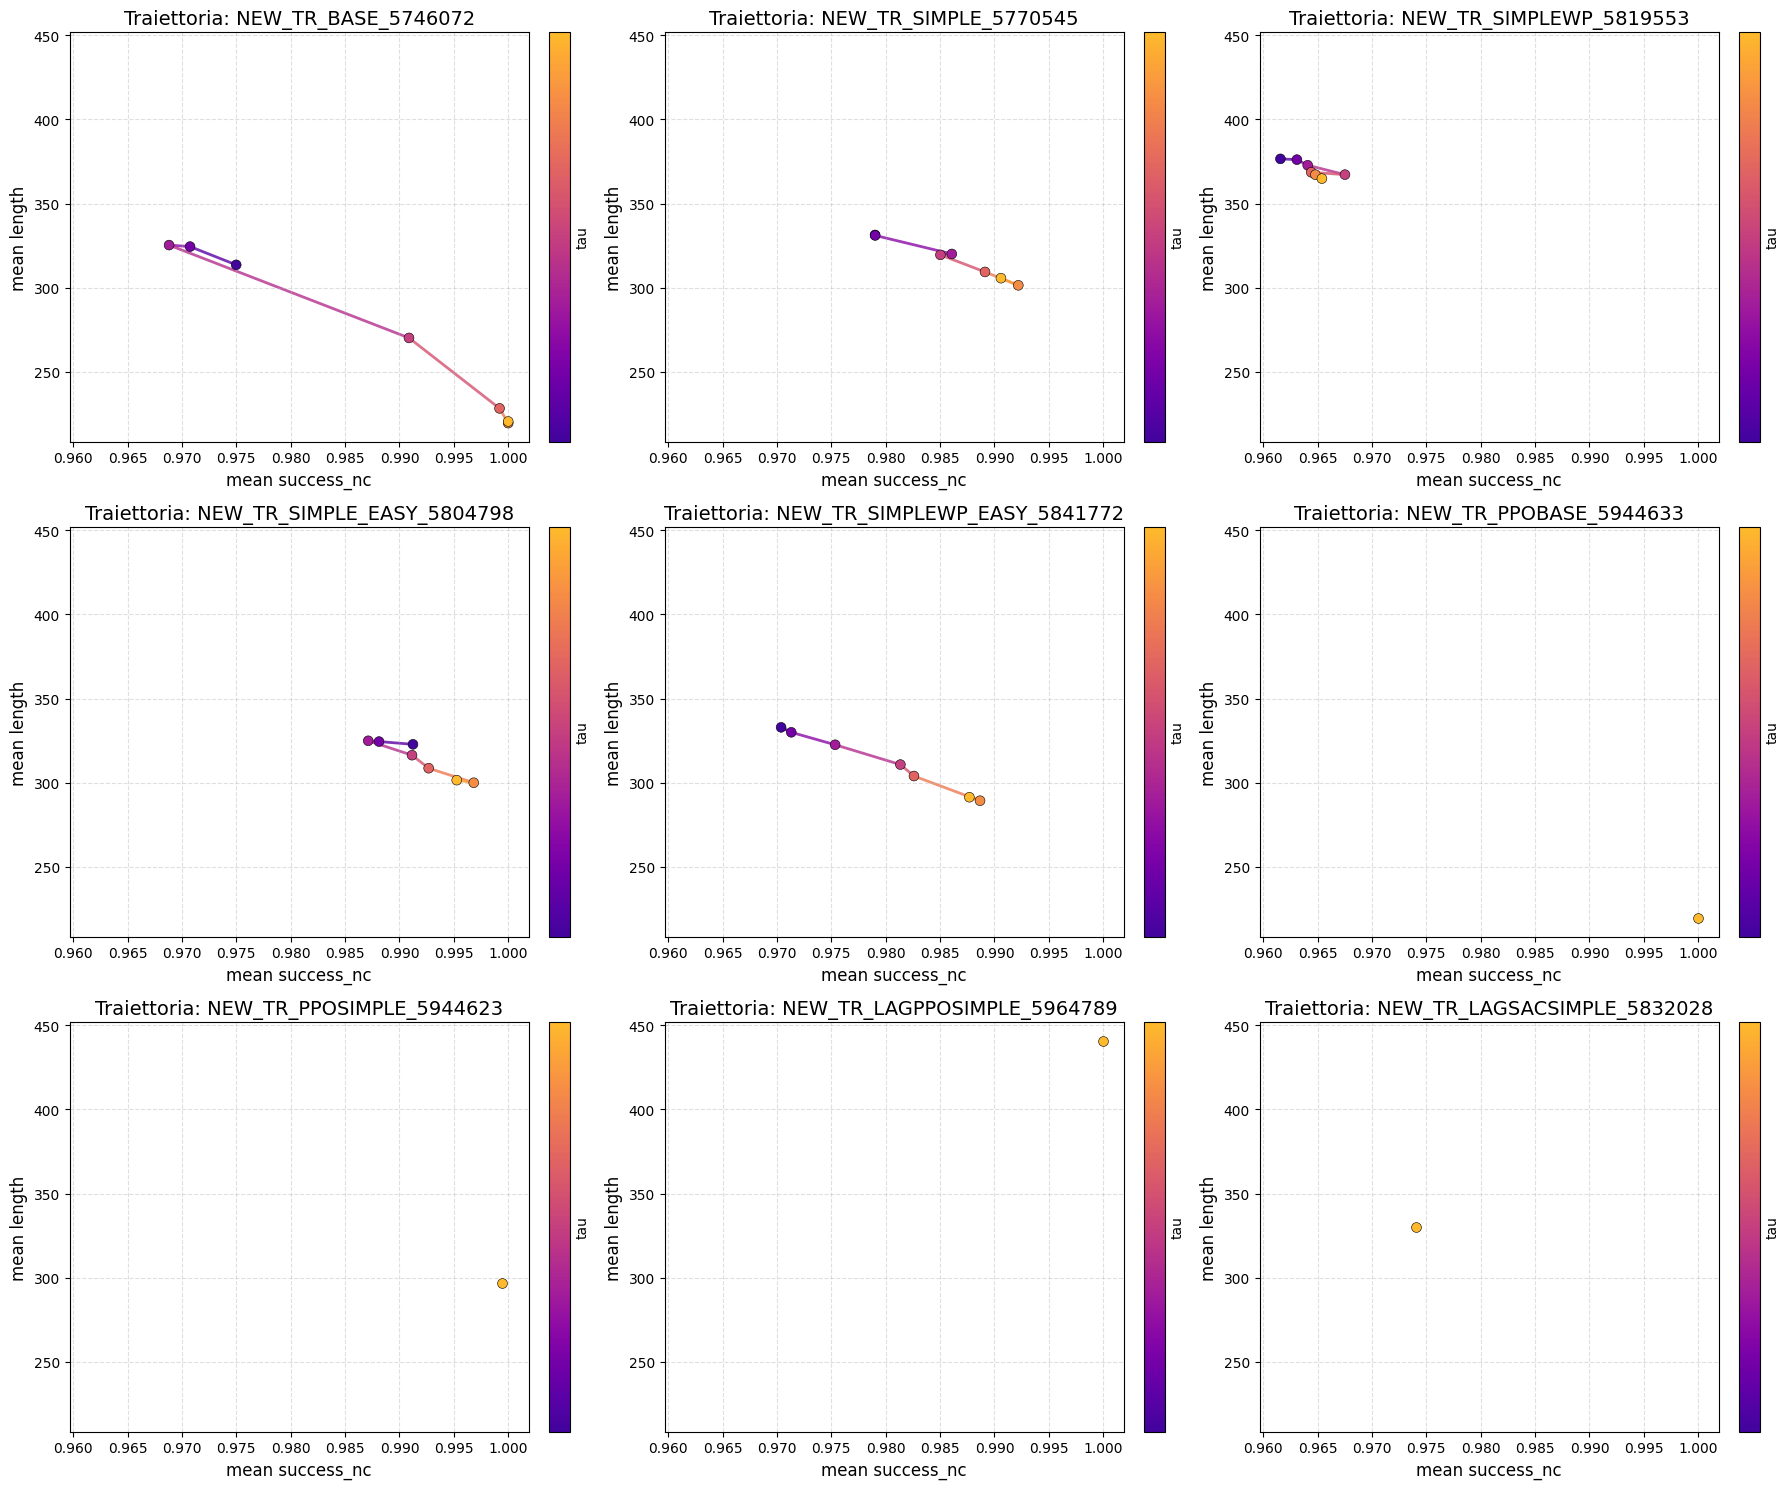

In [62]:
multy_plot_traiettorie(all_data_summary, 'success_nc', 'length', p_names, assi_globali=True);

# OOD1

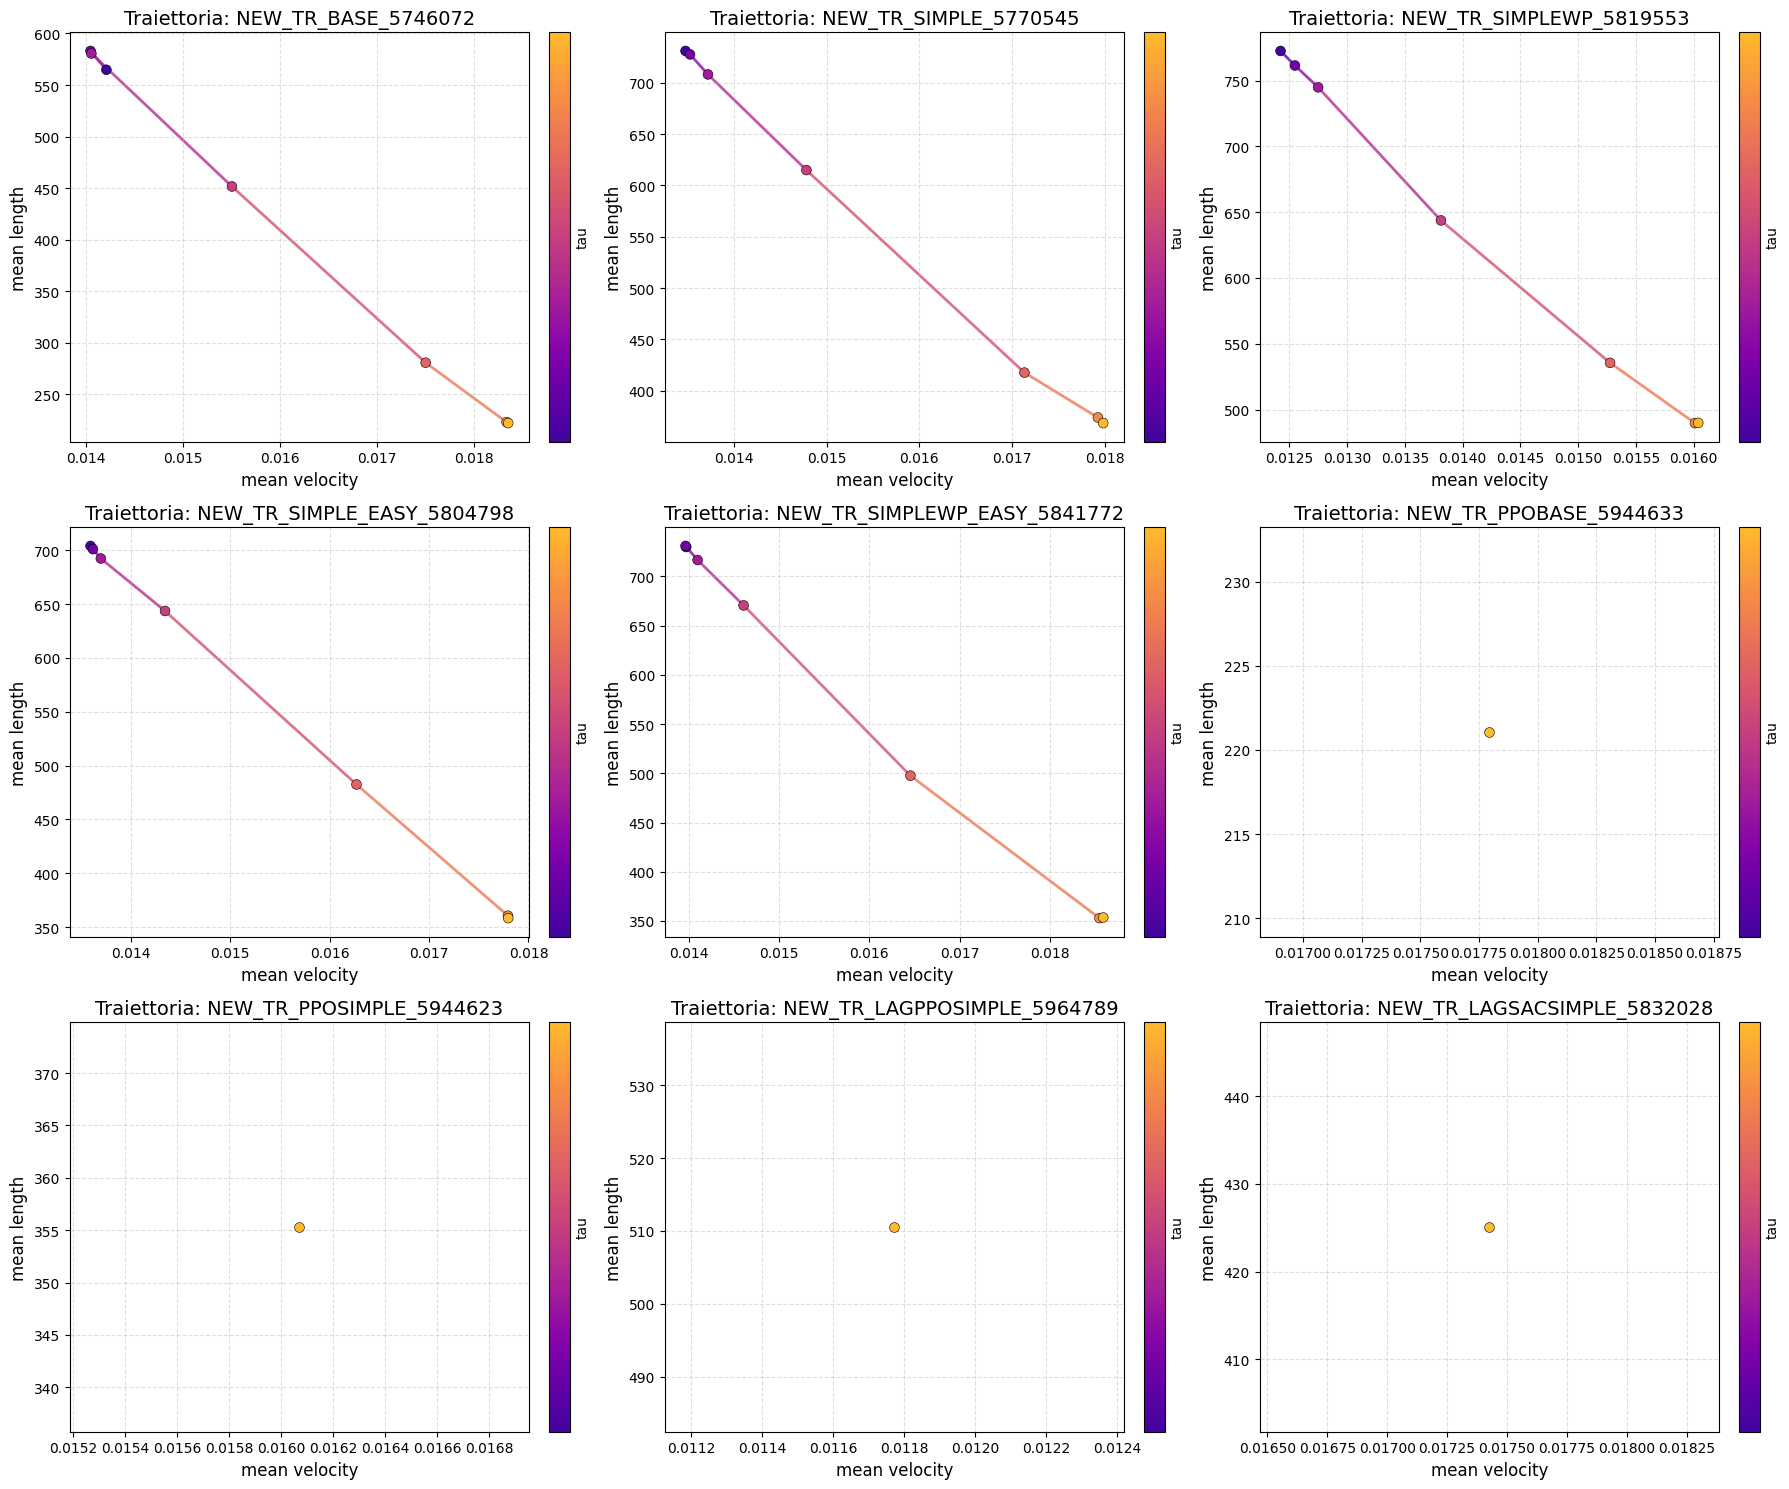

In [63]:
multy_plot_traiettorie(all_data_summary_ood1, 'velocity', 'length', p_names, assi_globali=False);

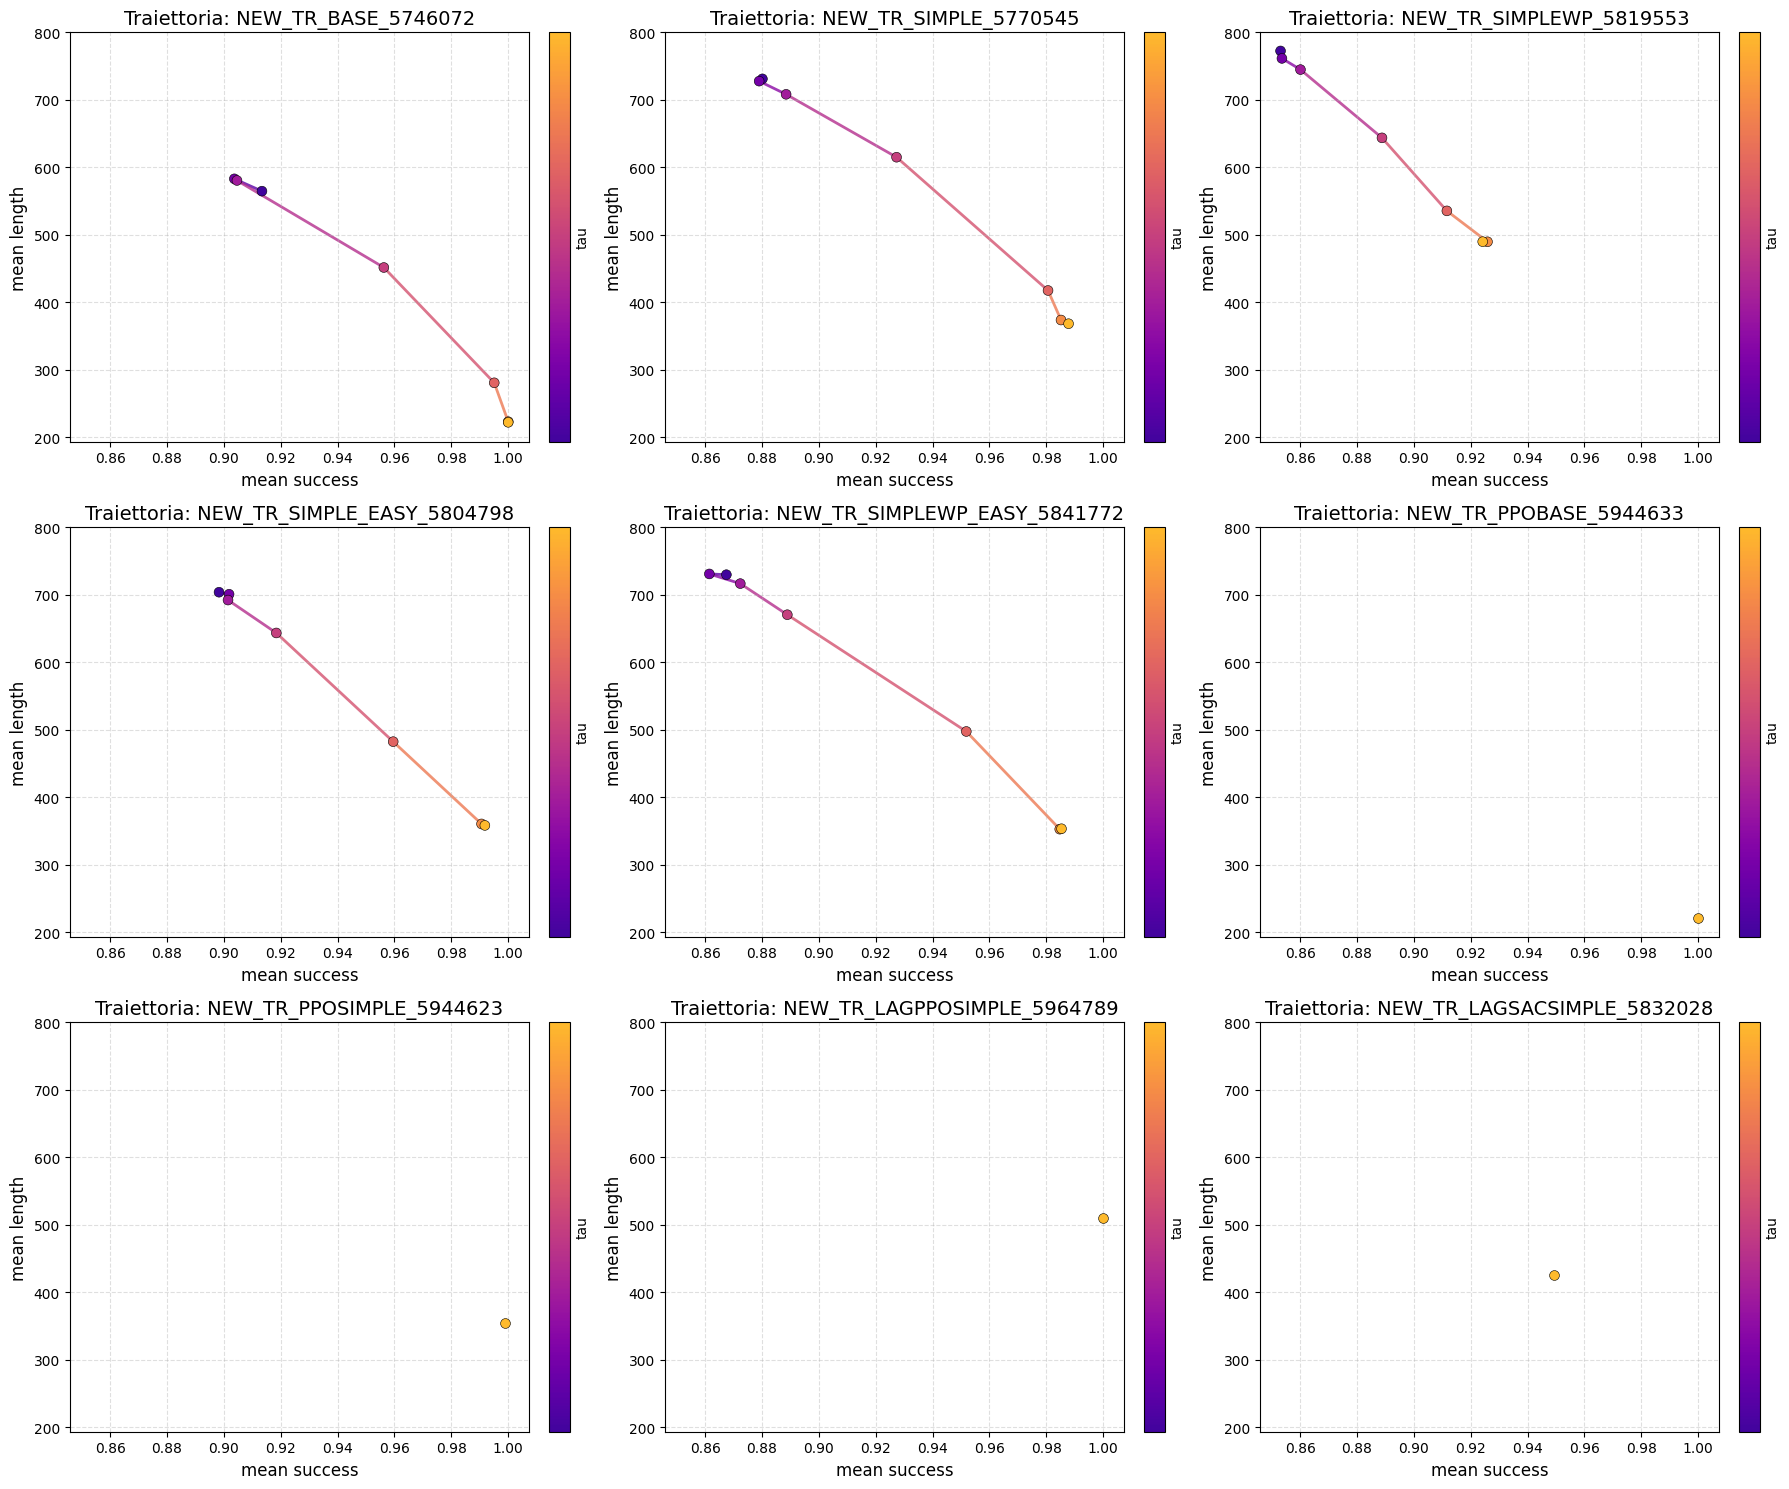

In [64]:
multy_plot_traiettorie(all_data_summary_ood1, 'success', 'length', p_names, assi_globali=True);

# OOD2

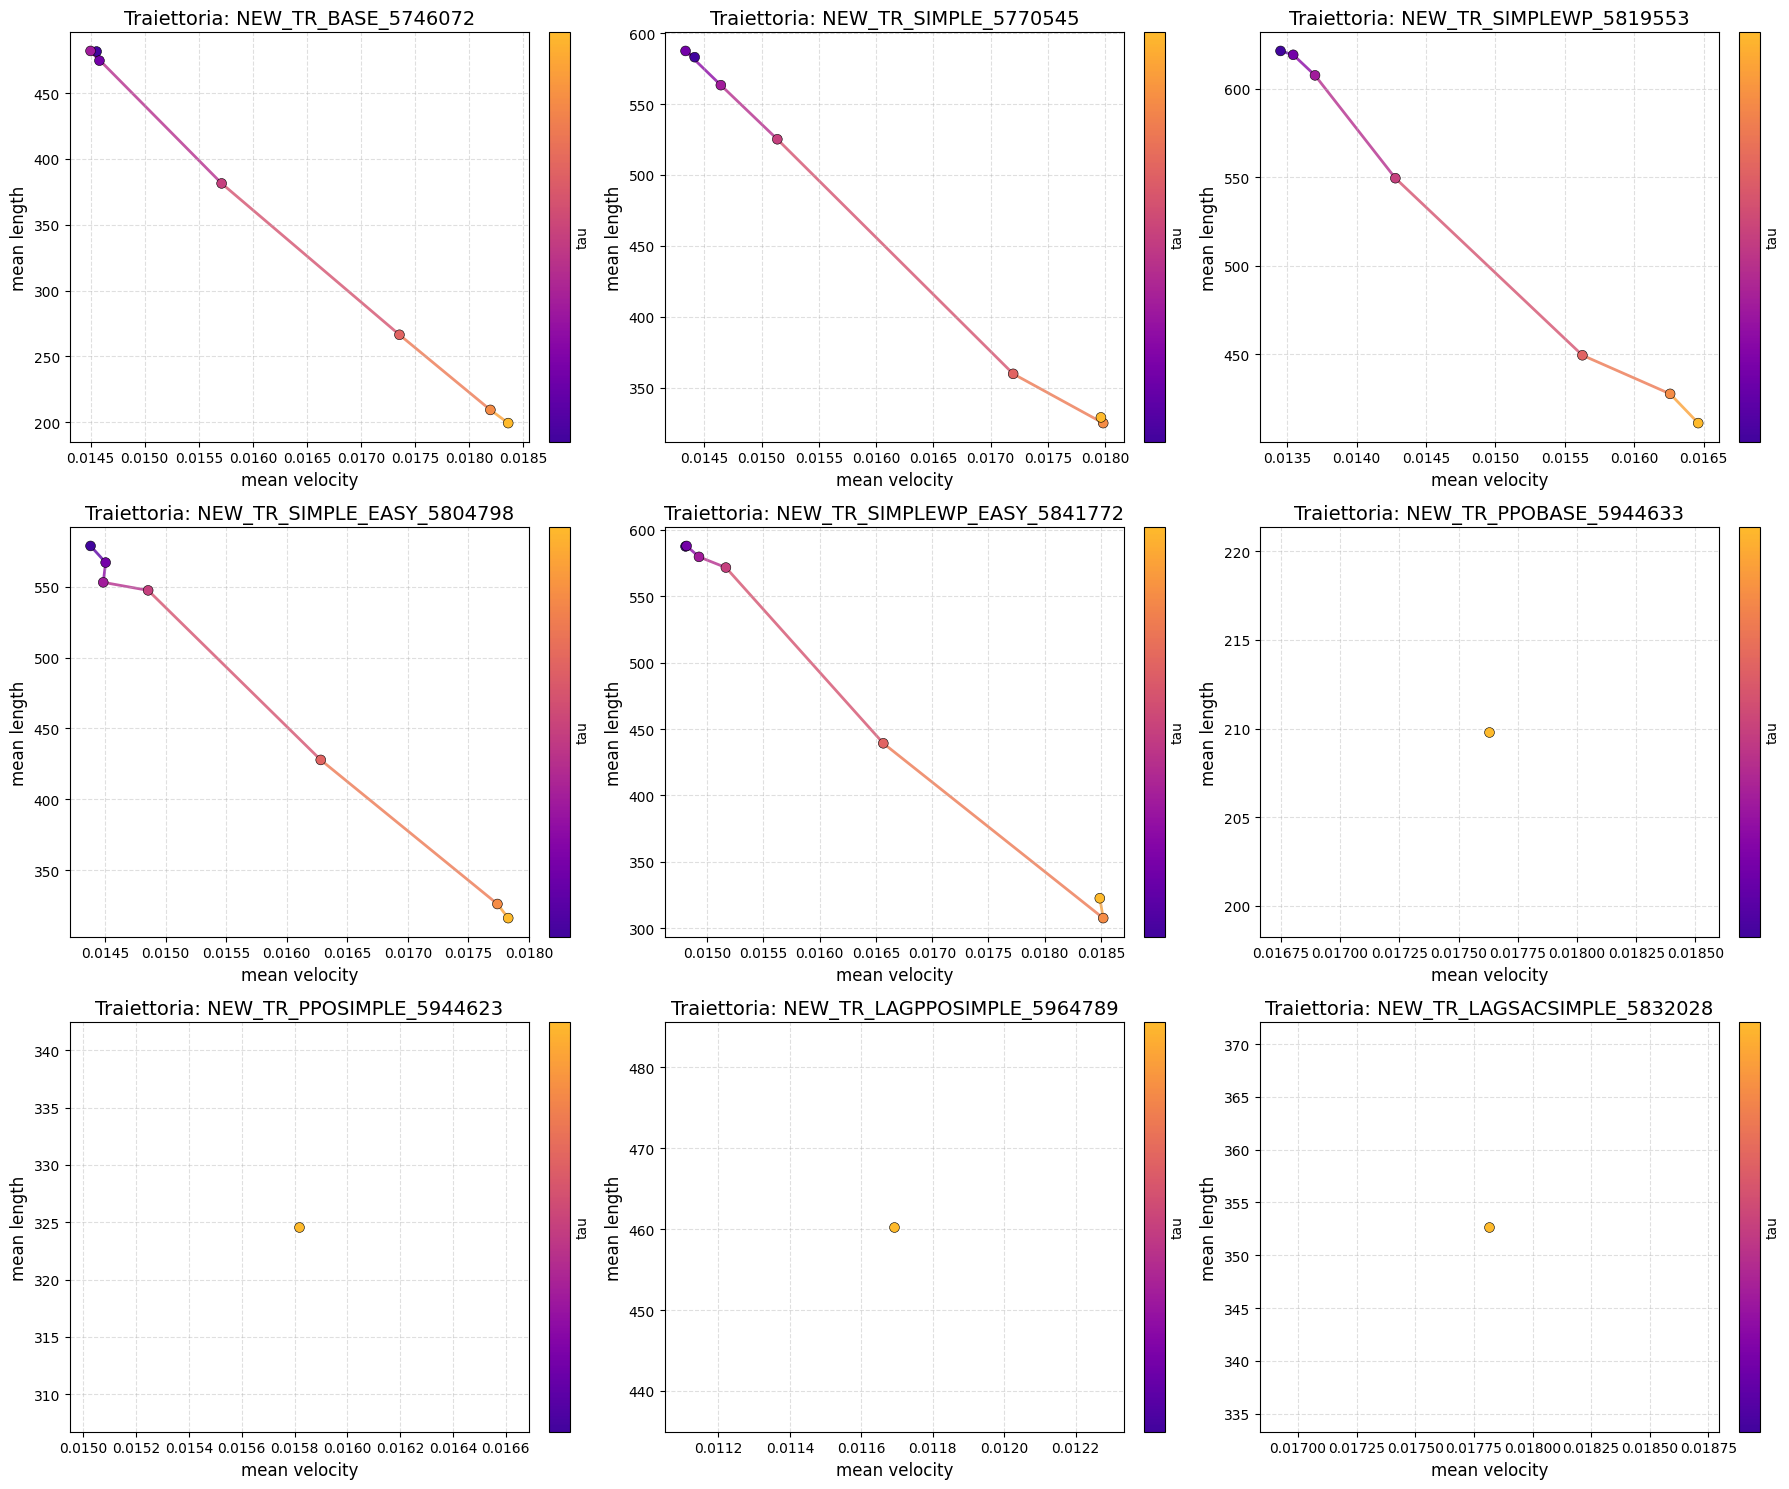

In [65]:
multy_plot_traiettorie(all_data_summary_ood2, 'velocity', 'length', p_names, assi_globali=False);

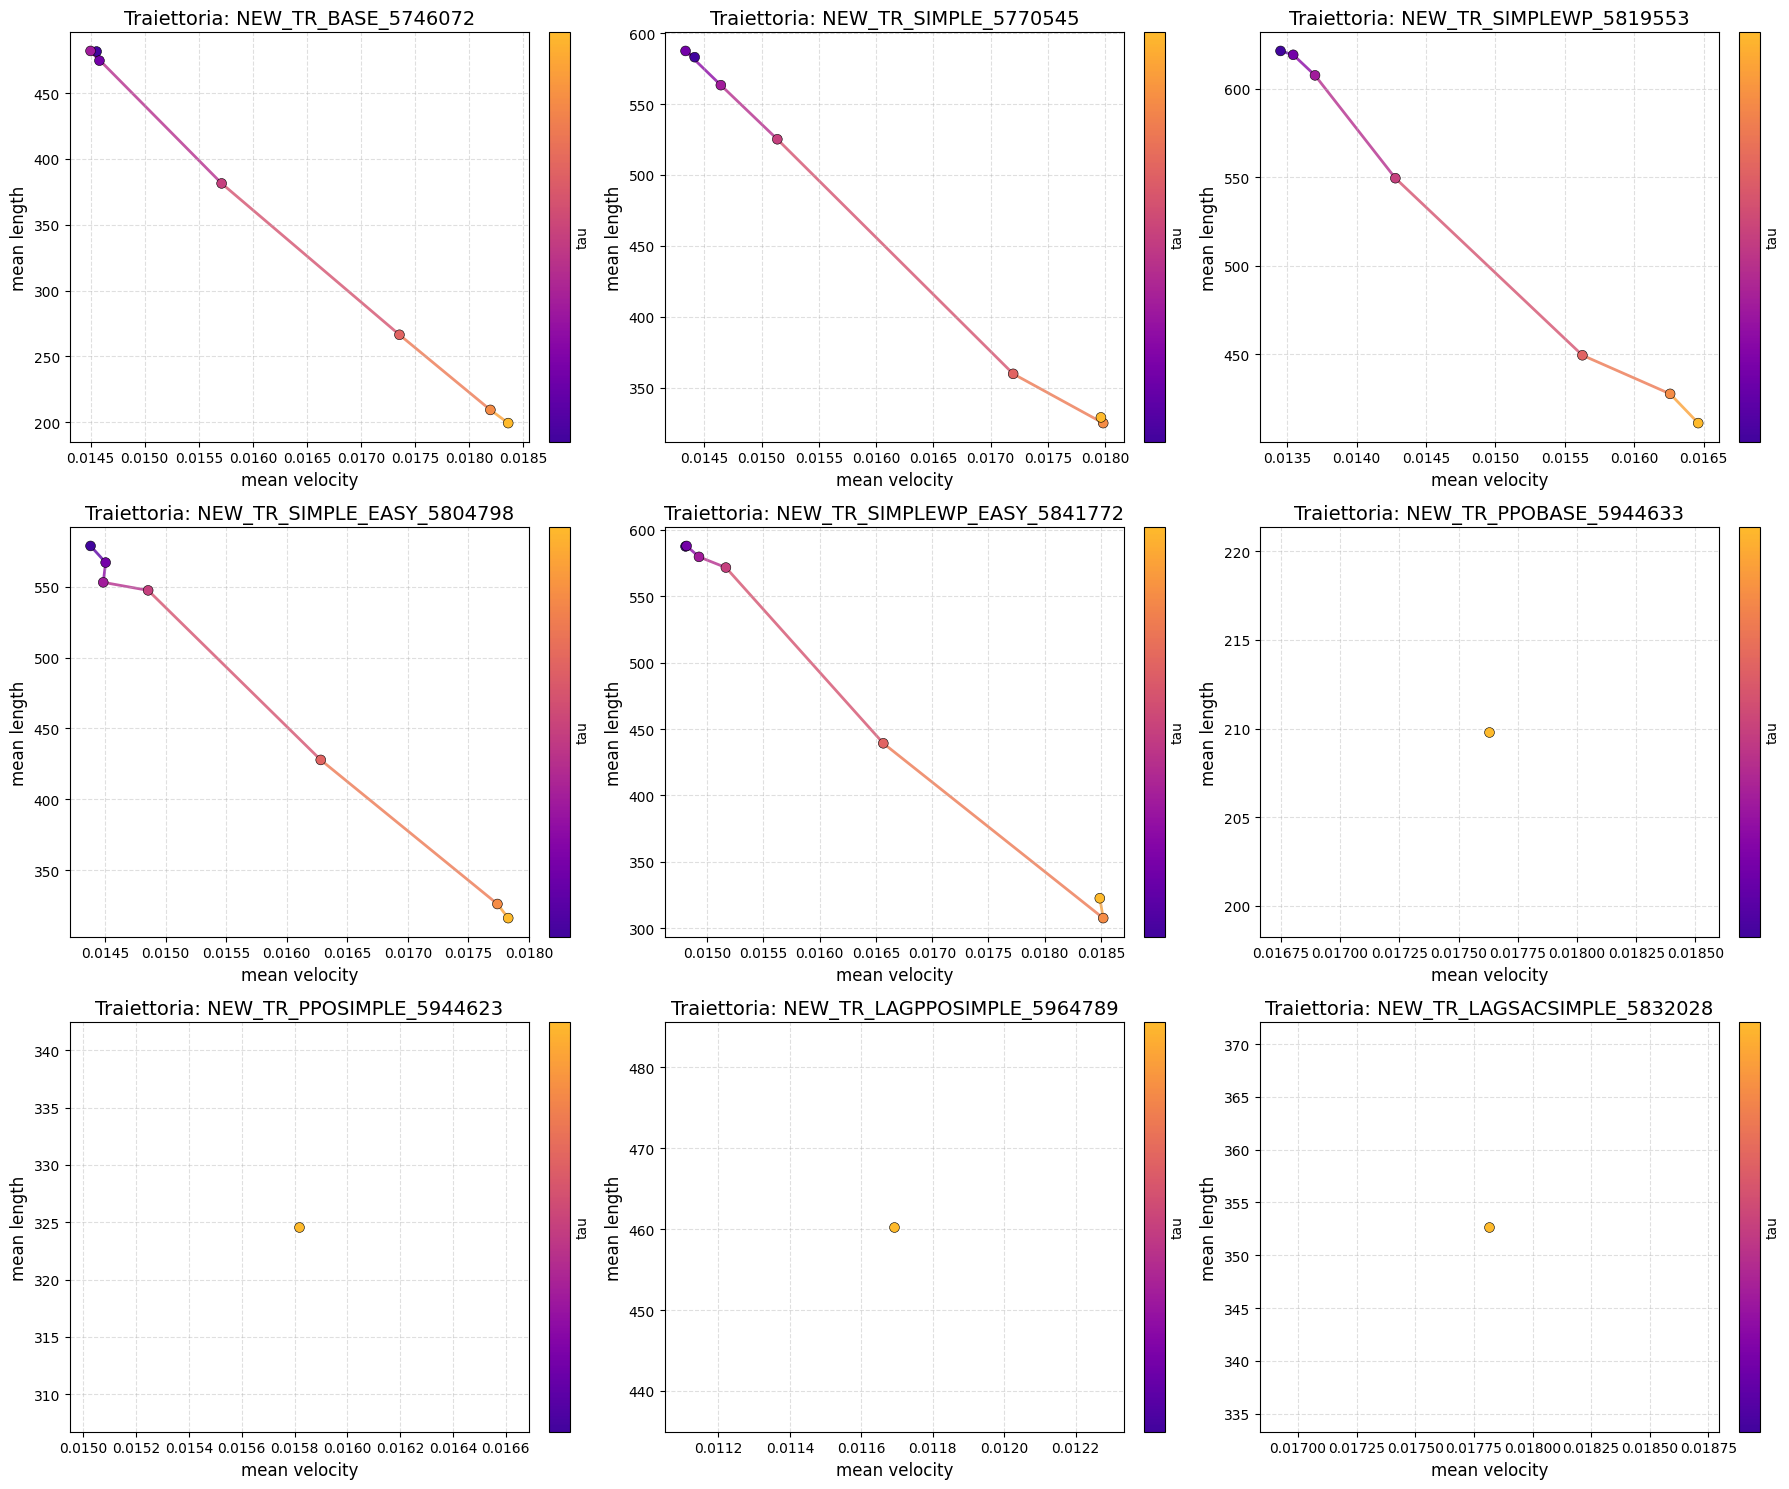

In [66]:
multy_plot_traiettorie(all_data_summary_ood2, 'velocity', 'length', p_names, assi_globali=False);

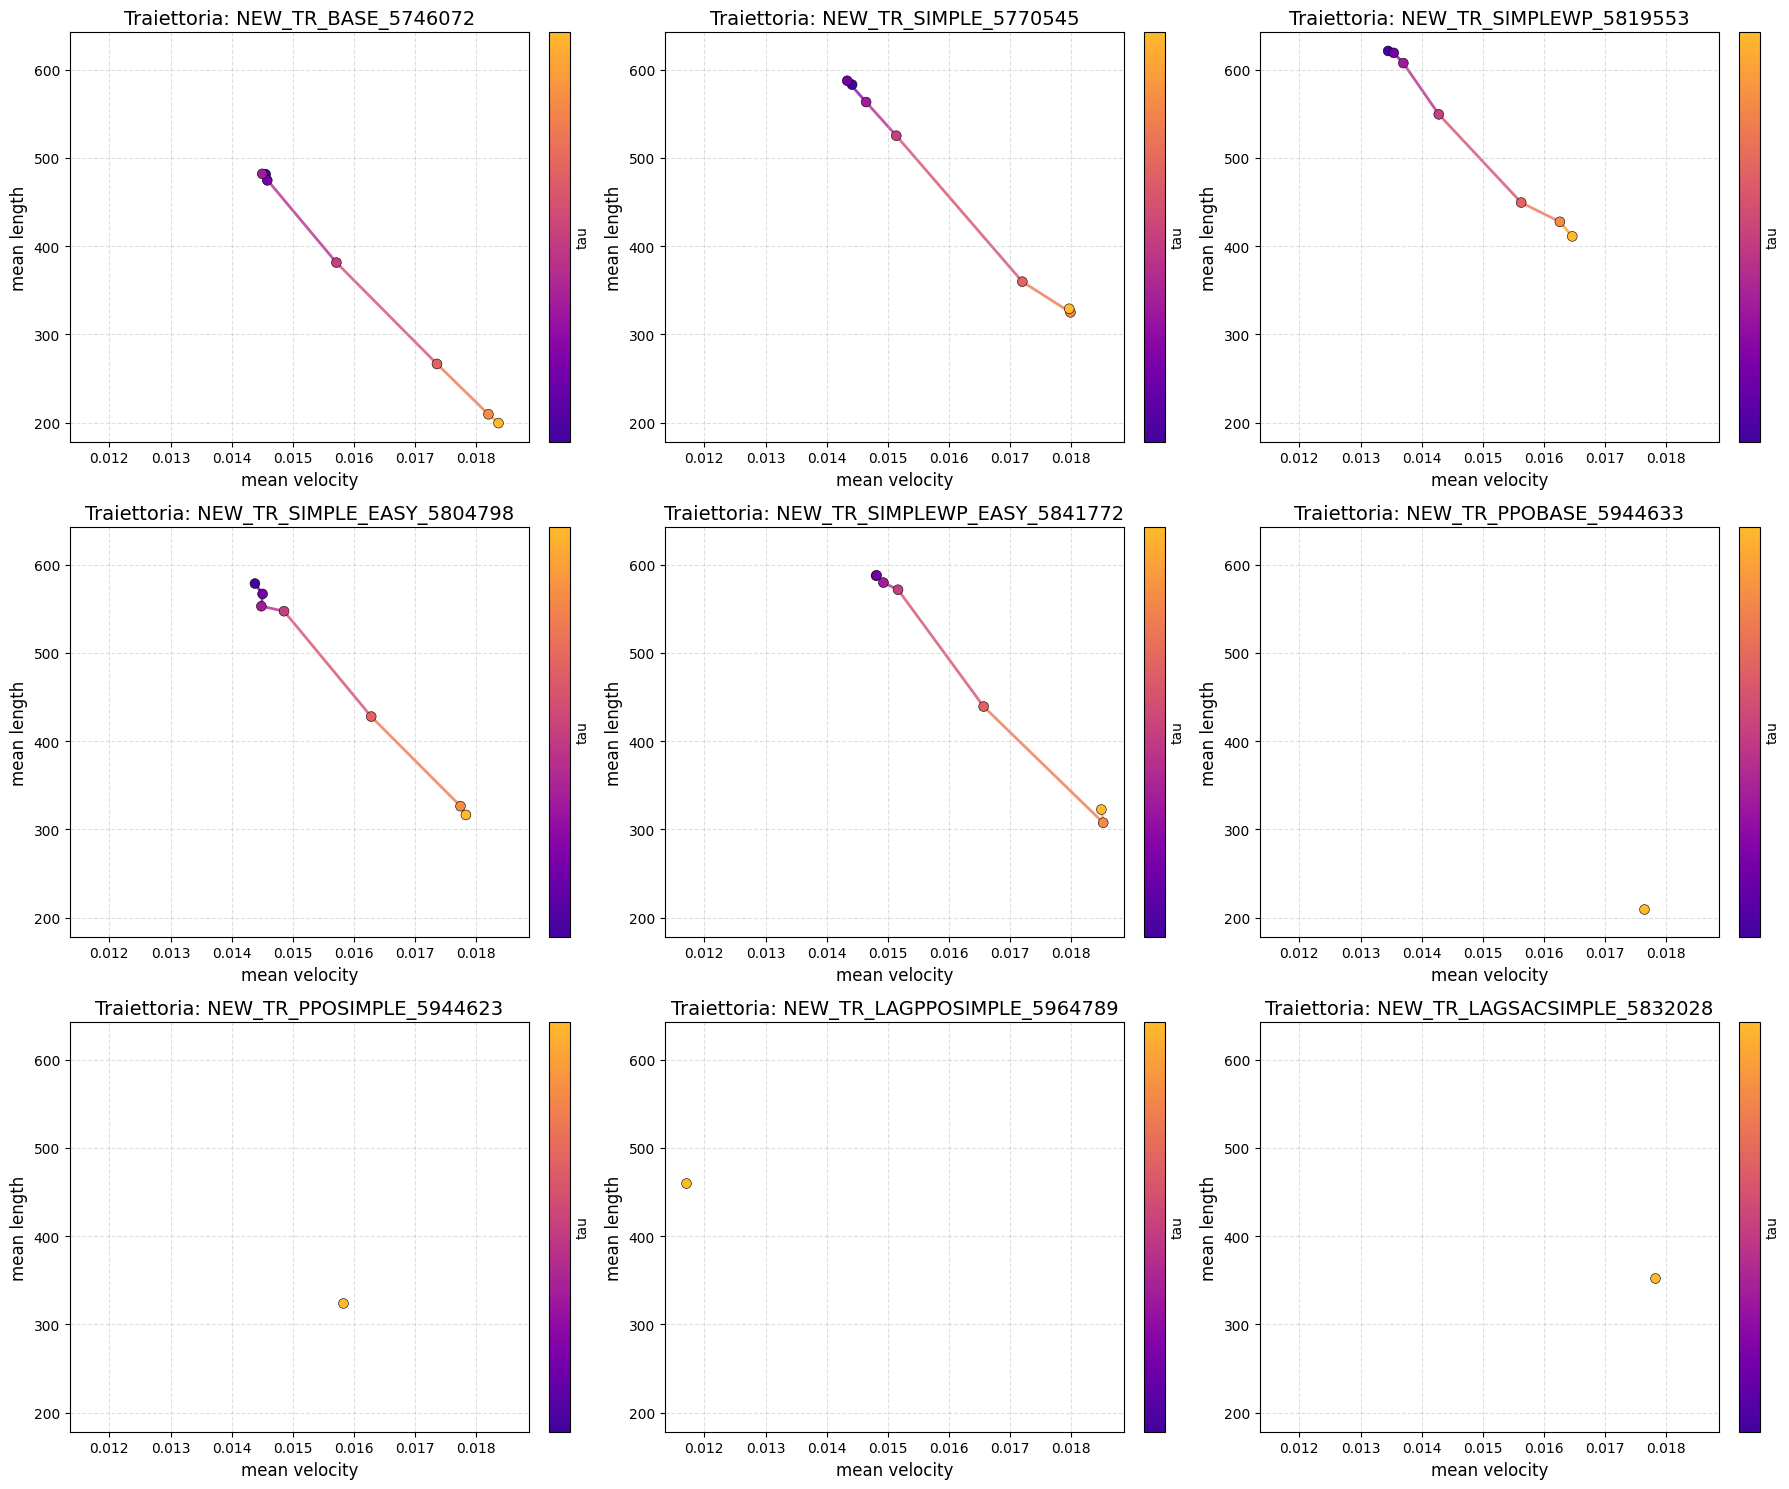

In [67]:
multy_plot_traiettorie(all_data_summary_ood2, 'velocity', 'length', p_names, assi_globali=True);

# OOD3

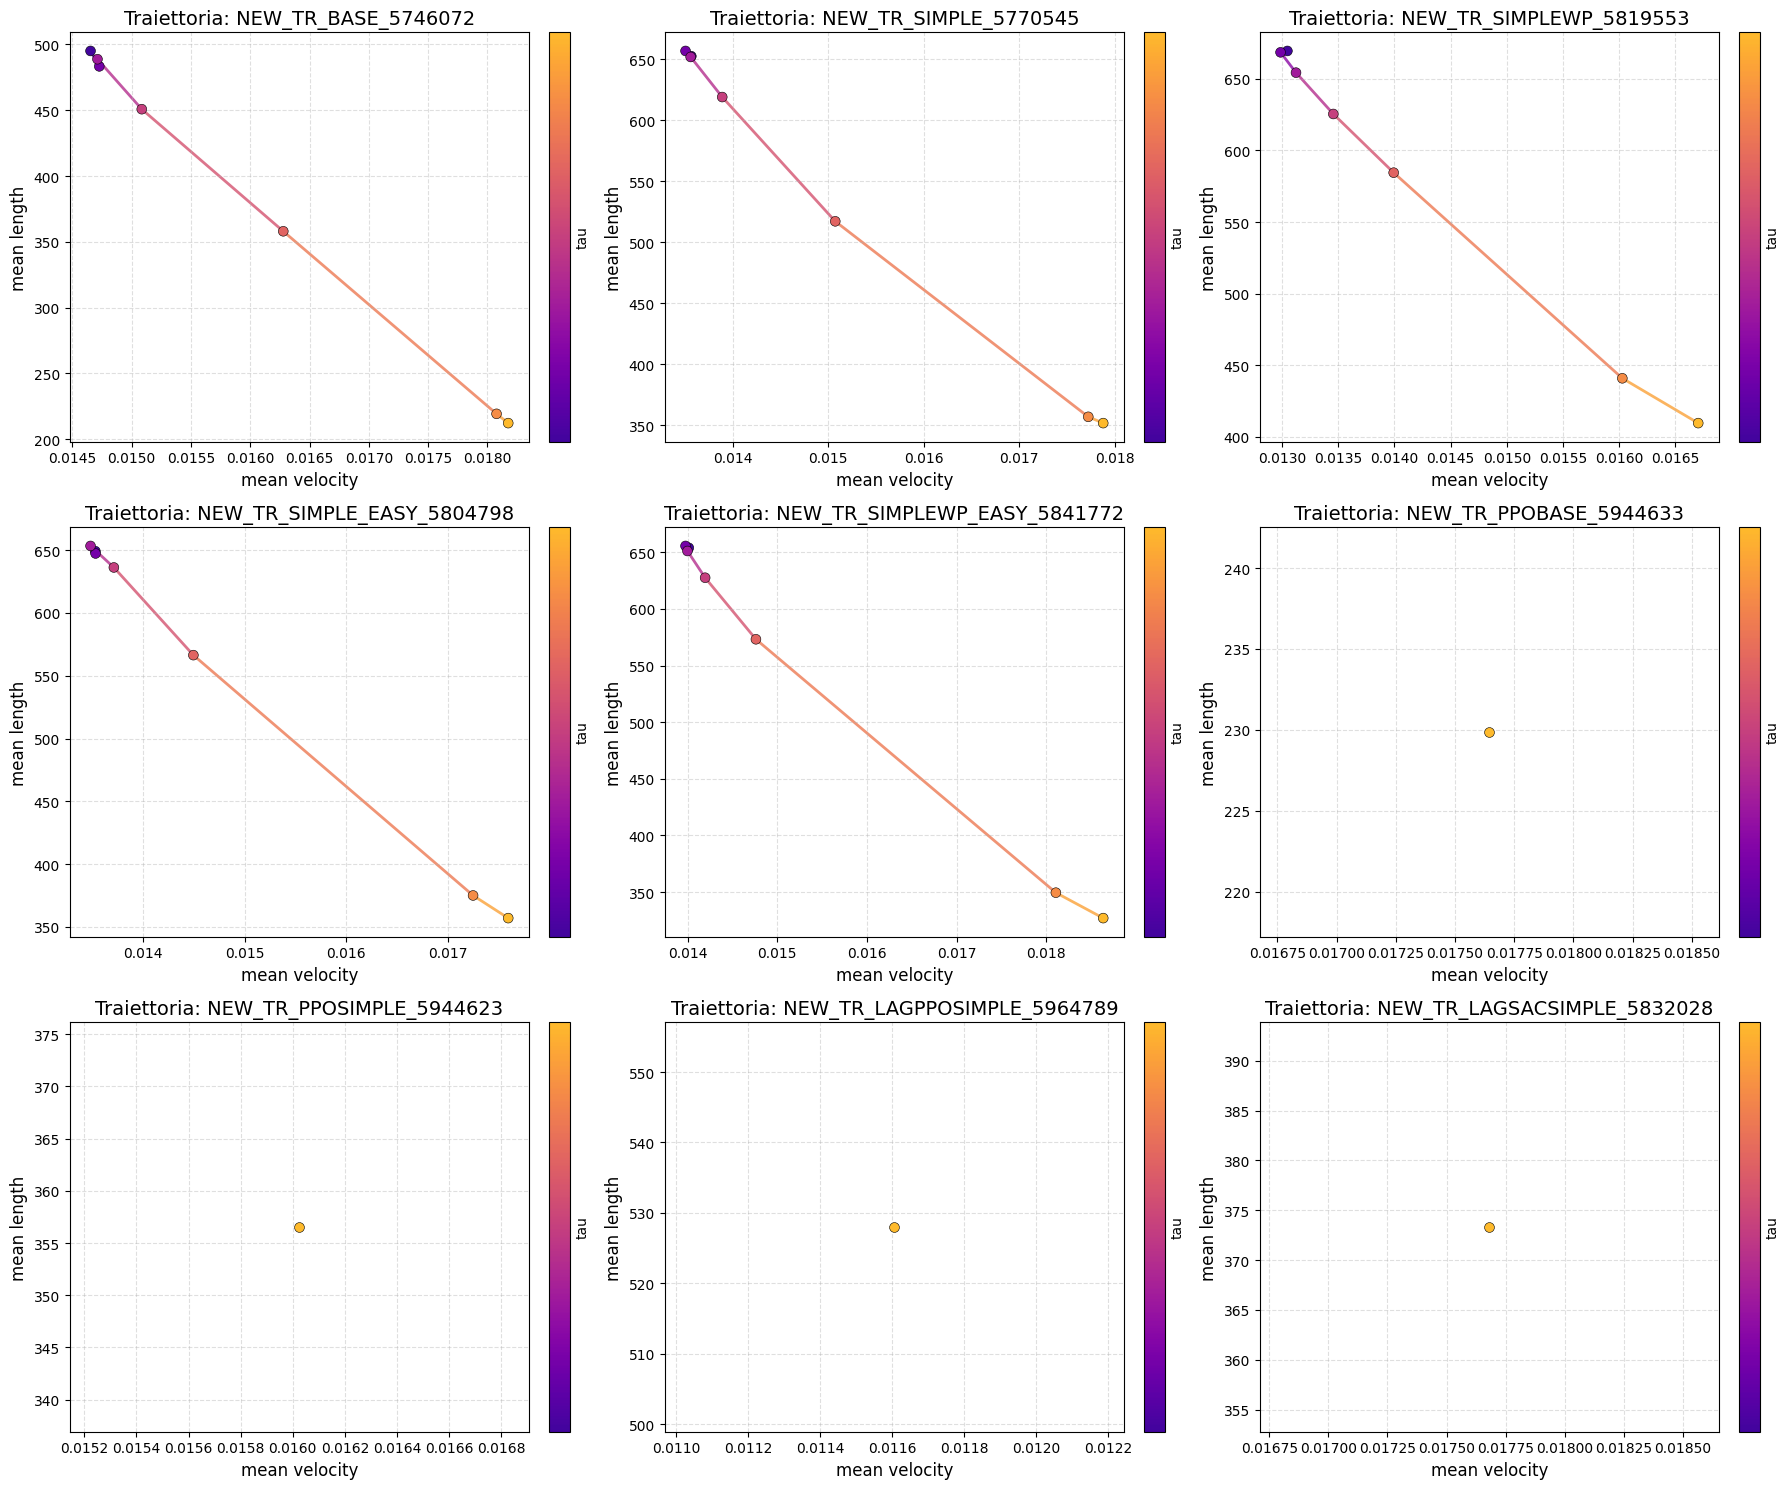

In [68]:
multy_plot_traiettorie(all_data_summary_ood3, 'velocity', 'length', p_names, assi_globali=False);

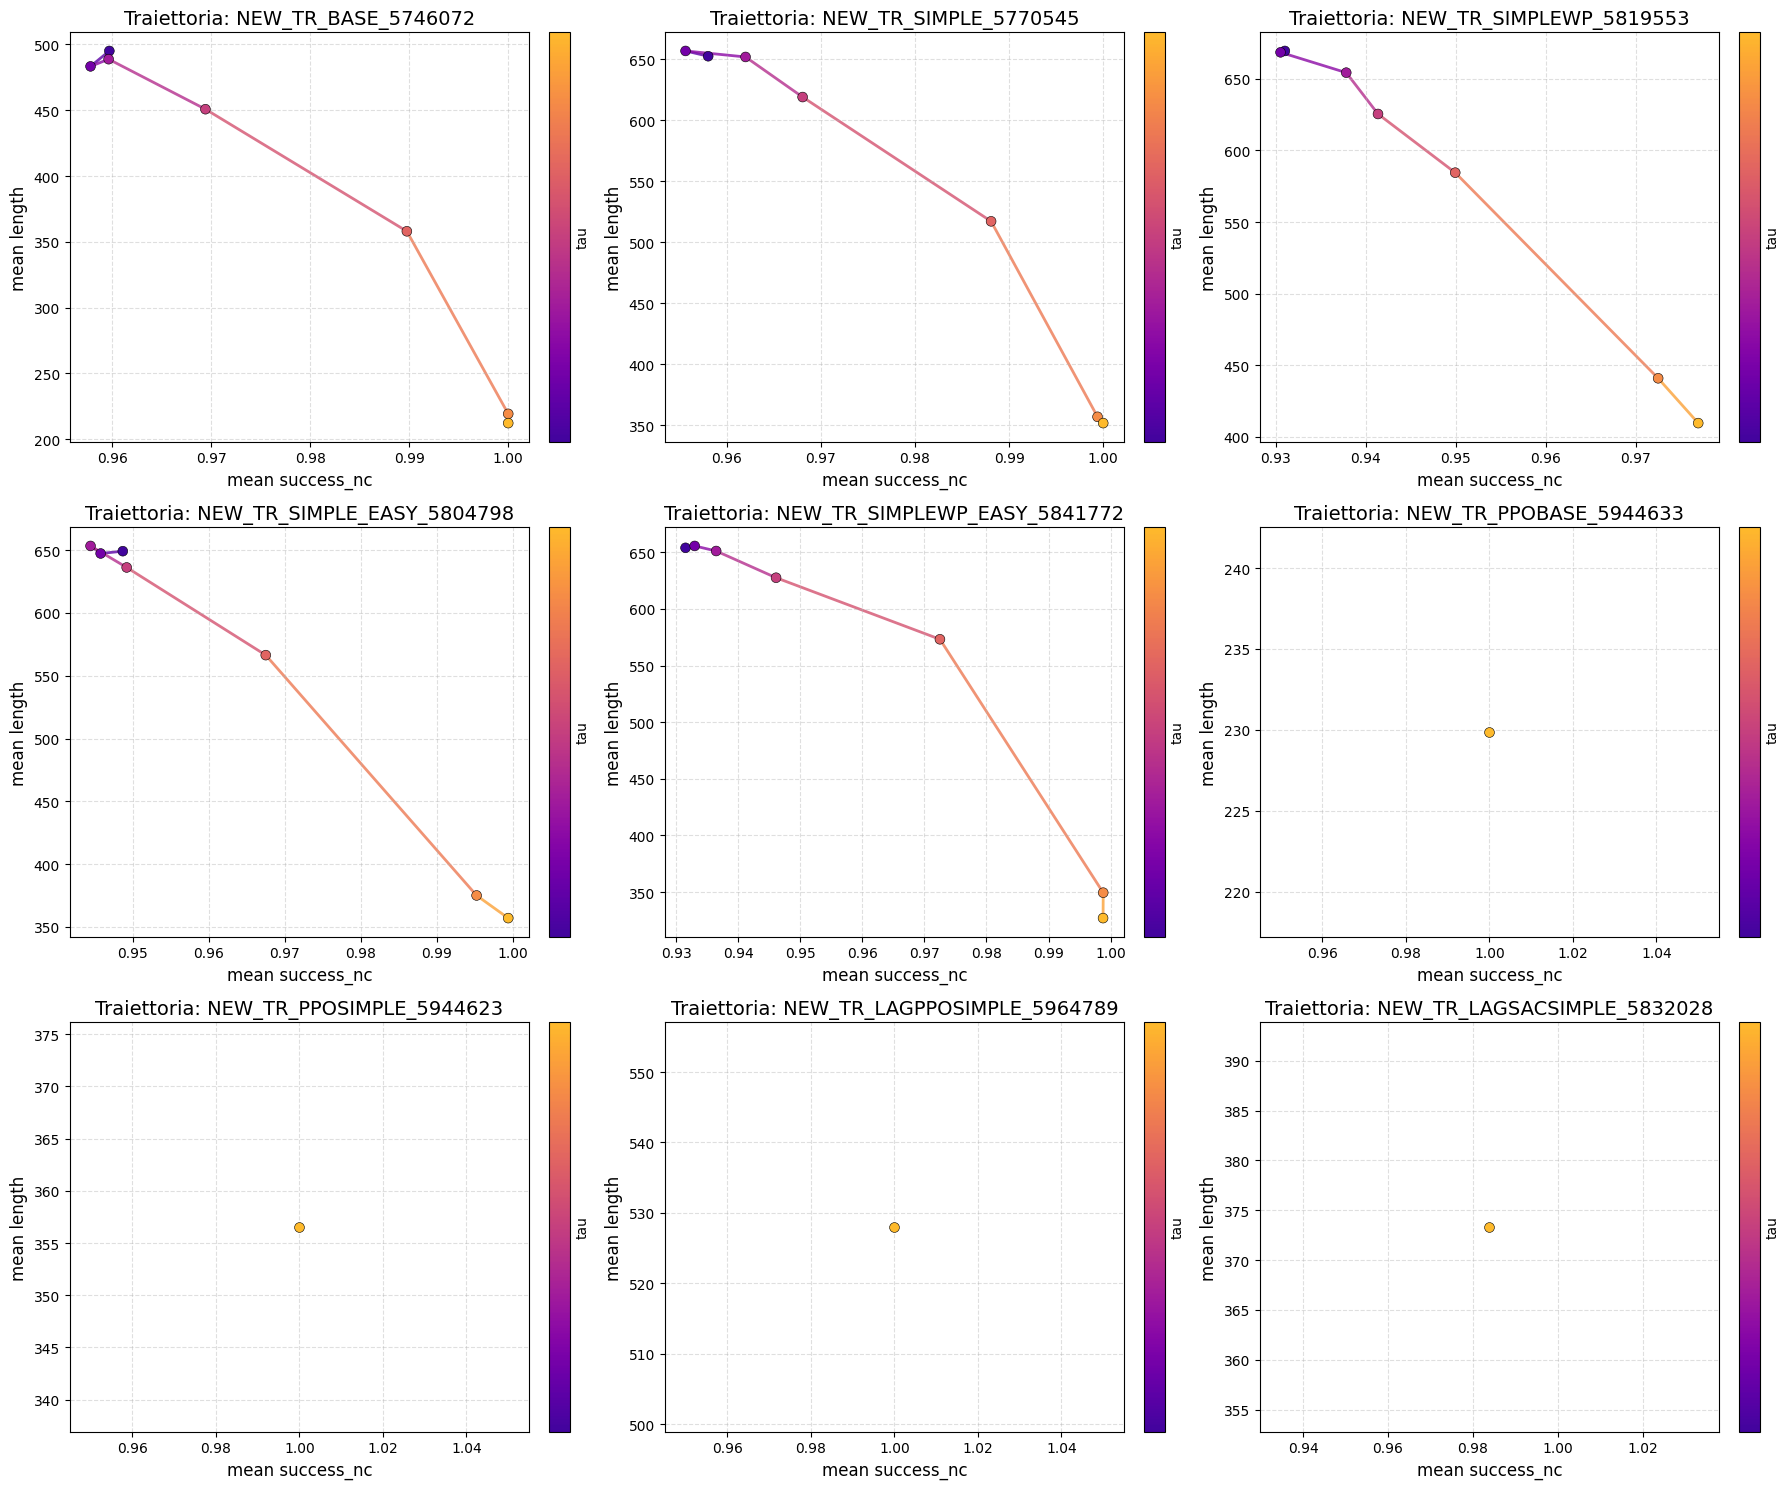

In [69]:
multy_plot_traiettorie(all_data_summary_ood3, 'success_nc', 'length', p_names, assi_globali=False);

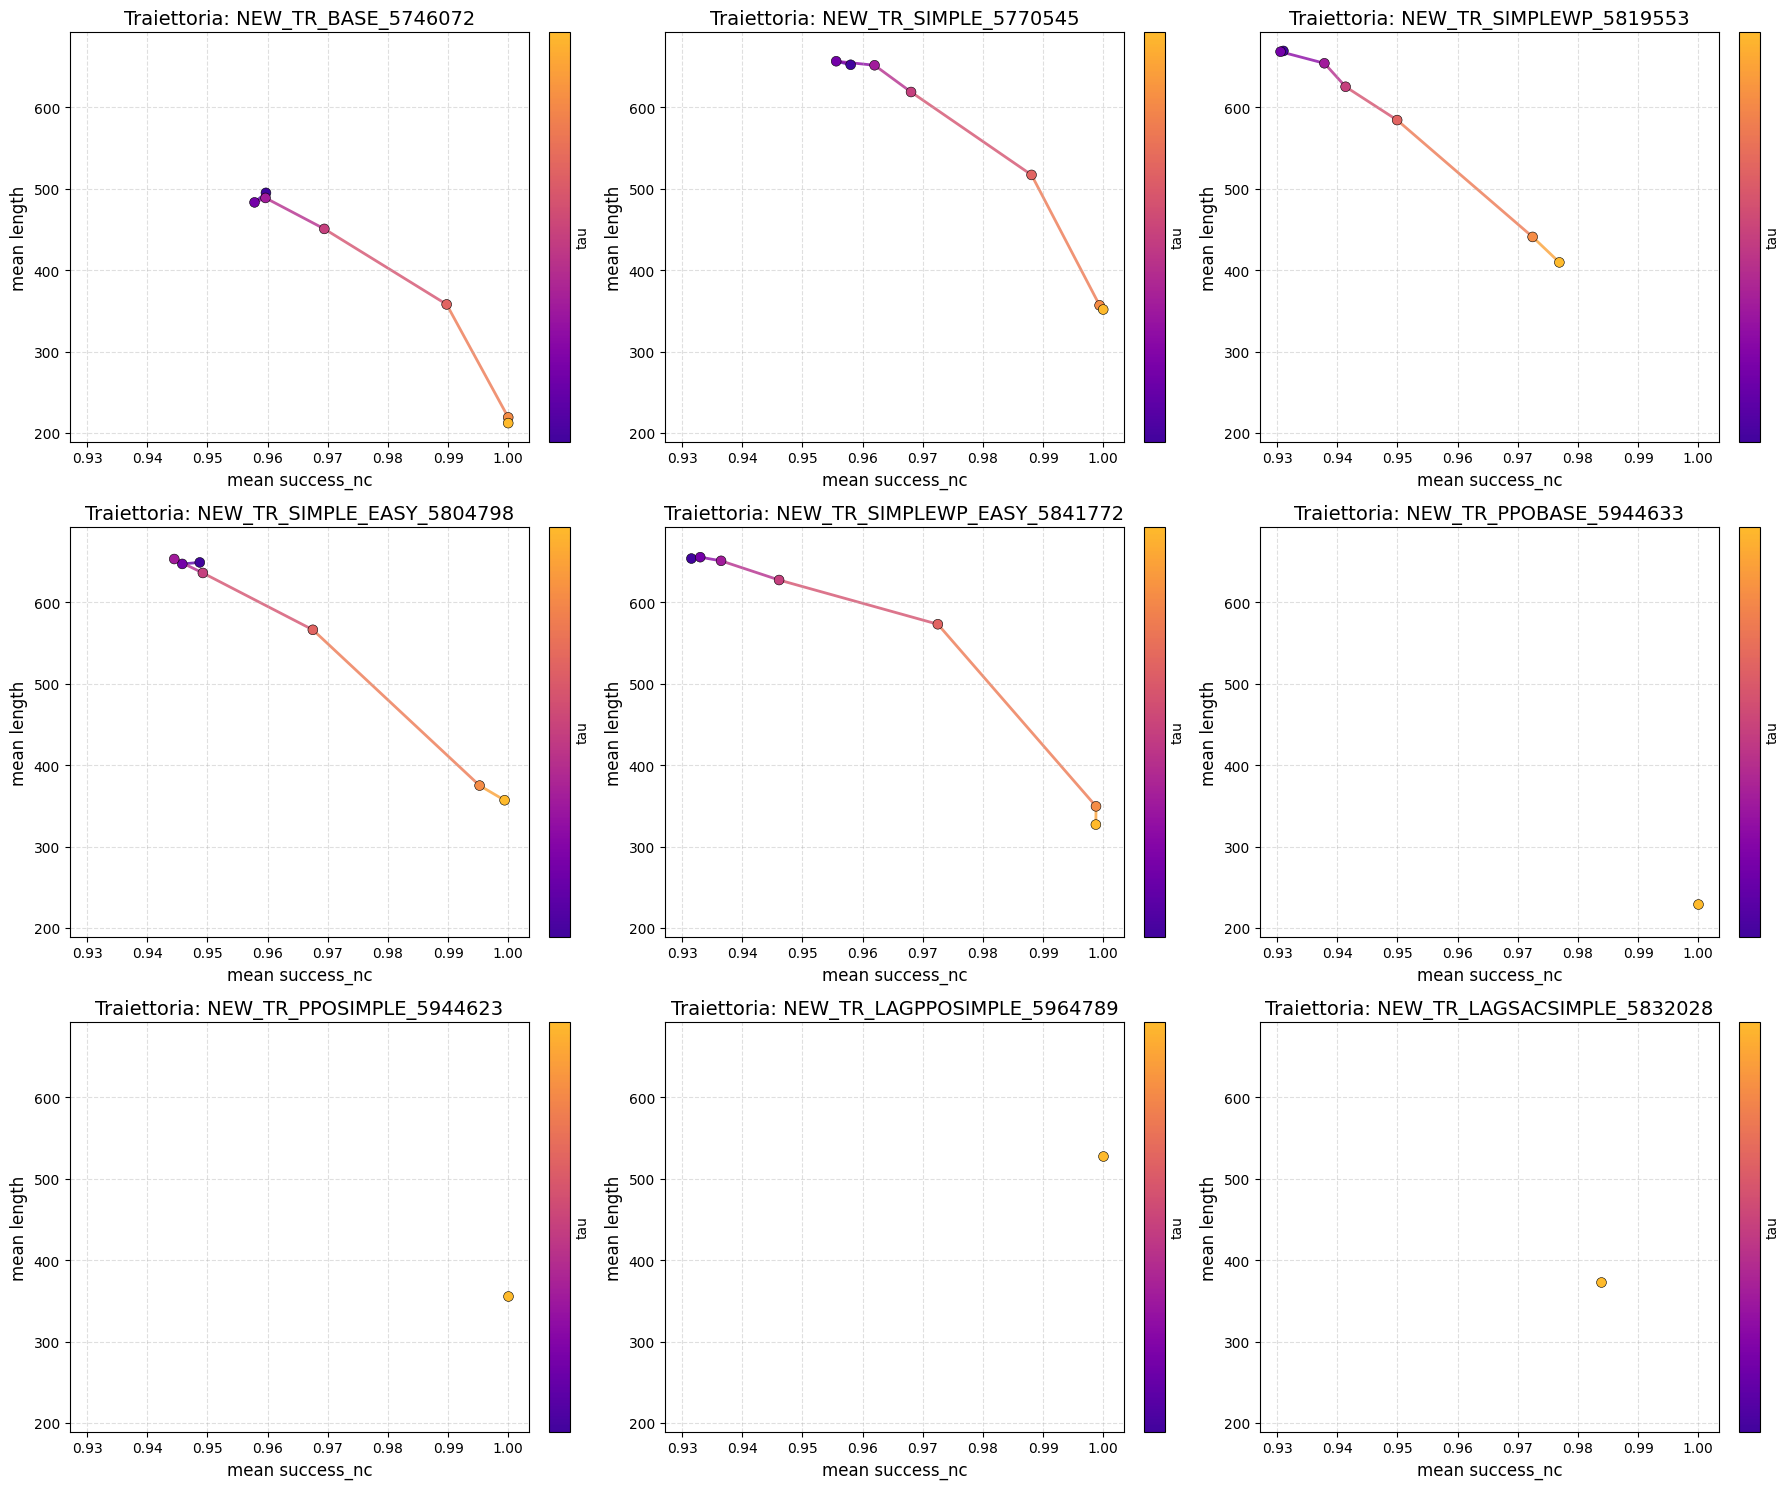

In [70]:
multy_plot_traiettorie(all_data_summary_ood3, 'success_nc', 'length', p_names, assi_globali=True);